# F1 - Statistics for each Era (1950-2025)

Per-era deep-dives across F1 history. Each era gets:

1. A **markdown explanation** - what defined the era, its World Champions, key events
2. A **top-10 drivers** chart - ranked by win rate (`wins / starts`), min 5 starts
3. A **wins-per-constructor-per-season** stacked bar - with annotated historical events

## Eras (9 total)
1. Pre-aerodynamic / Front-engine (1950-1958)
2. Rear-engine revolution (1959-1967)
3. Wings & aerodynamics (1968-1982)
4. Turbo era (1983-1988)
5. Active suspension / post-turbo (1989-1993)
6. Driver-aid ban / pre-V10 dominance (1994-1999)
7. V10 era (2000-2005)
8. V8 / Limited electronics (2006-2013)
9. Hybrid V6 Turbo (2014-2025)

## Cross-era charts (after the per-era loop)

| # | Question |
|---|---|
| 6.2a | All eras on one chart - driver win rate vs year, era-colored |
| 6.2b | Era competitiveness gap - P1 vs P10 win-rate spread per era |
| 6.3  | Drivers who raced across the most eras |
| 6.4  | Within-season pattern (early vs mid vs late races) per era |
| 6.5  | Change in points distribution between seasons (normalized) |
| 6.6  | (meta) where to apply mean / mode / variance |


## Setup — imports and data loading

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from f1_utils import (
    show_and_save, eras_df, year_to_era, apply_default_style,
)
apply_default_style()

sns.set_theme(style='whitegrid')

drivers      = pd.read_csv('excel/drivers.csv')
results      = pd.read_csv('excel/results.csv')
races        = pd.read_csv('excel/races.csv')
constructors = pd.read_csv('excel/constructors.csv')
circuits     = pd.read_csv('excel/circuits.csv')
qualifying   = pd.read_csv('excel/qualifying.csv')
standings    = pd.read_csv('excel/driver_standings.csv')

print('drivers     :', drivers.shape)
print('results     :', results.shape)
print('races       :', races.shape)
print('constructors:', constructors.shape)
print('circuits    :', circuits.shape)
print('qualifying  :', qualifying.shape)
print('standings   :', standings.shape)

## Data cleanup — Indianapolis 500 (1950–1960)

The Indy 500 was nominally part of the F1 World Championship from **1950 to 1960** but was a separate American oval race. Most "F1 drivers" appearing in those rows never raced anywhere else in F1, which pollutes per-driver statistics (drivers who never won, youngest pole sitter, best debut, etc.).

We strip these entries **once at the source** so every downstream analysis is clean. This is the kind of data quality decision a real analyst makes — the rules of the championship and the *sport* aren't the same thing.

In [ ]:
# Identify Indy 500 races and drop them from results, qualifying, races
indy_race_ids = races.loc[
    races['name'].str.contains('Indianapolis', case=False, na=False),
    'raceId'
]

n_before_results = len(results)

results    = results   [~results   ['raceId'].isin(indy_race_ids)].copy()
qualifying = qualifying[~qualifying['raceId'].isin(indy_race_ids)].copy()
races      = races     [~races     ['raceId'].isin(indy_race_ids)].copy()

print(f'Indy 500 races removed   : {len(indy_race_ids)}')
print(f'Result rows dropped      : {n_before_results - len(results):,}')
print(f'Clean dataset:')
print(f'  races      : {len(races):,}')
print(f'  results    : {len(results):,}')
print(f'  qualifying : {len(qualifying):,}')

Indy 500 races removed   : 11
Result rows dropped      : 405
Clean dataset:
  races      : 1,114
  results    : 26,354
  qualifying : 10,494


---
# F1 Eras — reference table

Many later questions ask things like *"who is the best driver in each era?"* or
*"what was pit-stop time per era?"*. To answer them consistently, we first build
a single source of truth: a small `eras_df` DataFrame that lists every era,
its boundaries, engine formula, and a short description.

Then we add an `era_id` column to `races` so every downstream analysis can
simply do `.merge(eras_df, on='era_id')` or `.groupby('era_id')`.

### Notes on the source list
- The original list had **overlapping years** (1959–60 appeared in two eras,
  1968 in two eras). We resolve overlaps by giving the later era priority on
  the boundary year — so e.g. 1968 belongs to "Wings & aerodynamics", not to
  "Rear-engine revolution".
- The original list had a **gap from 1994 to 1999**. That period was a real,
  distinct era: traction control / active suspension banned after Senna's
  death, Schumacher's first titles with Benetton, V10 engines becoming the
  standard. We add it as a 9th era (`Driver-aid ban / pre-V10 dominance`).

In [ ]:
# Step 1 — build the era reference table
eras = [
    # (era_id, name_ru,                                                    name_en,                                year_start, year_end, engine,                       dominant_team_or_driver,        key_feature)
    (1, 'Пред-аэродинамическая / Переднемоторная эра',                     'Pre-aerodynamic / Front-engine',       1950, 1958, 'Front-engine, NA 1.5L s/c or 4.5L NA', 'Alfa Romeo, Mercedes, Ferrari', 'No wings, no aero — driver skill on narrow tyres; Fangio wins 5 titles'),
    (2, 'Заднемоторная революция',                                          'Rear-engine revolution',               1959, 1967, 'NA 1.5–3.0L (rear-mounted)',           'Cooper, Lotus, BRM',           'Cooper proves the rear-engine layout; Jim Clark / Lotus dominance'),
    (3, 'Эра крыльев и аэродинамики',                                       'Wings & aerodynamics',                 1968, 1982, 'NA 3.0L (Cosworth DFV era)',          'Lotus, Ferrari, McLaren',      'First wings (1968), ground effect (Lotus 78/79), DFV available to all'),
    (4, 'Турбоэра',                                                          'Turbo era',                            1983, 1988, '1.5L turbo (up to ~1300 hp qual.)',    'McLaren-Honda, Williams-Honda', 'Renault pioneers turbos; Honda/Porsche dominate; Senna vs Prost'),
    (5, 'Золотая эра активной подвески / Бестурбоэра',                      'Active suspension / post-turbo',       1989, 1993, 'NA 3.5L V8/V10/V12',                  'Williams, McLaren',            'Active suspension, traction control, ABS; Williams FW14B'),
    (6, 'Запрет электроники / Пред-V10-эра',                                'Driver-aid ban / pre-V10 dominance',   1994, 1999, 'NA 3.0L (mixed V8/V10/V12)',          'Williams, Ferrari, McLaren',   'Active aids banned after Senna death; Schumacher 1st titles; V10 becomes standard'),
    (7, 'Эра V10 / Доминация Ferrari и Шумахера',                           'V10 era',                              2000, 2005, 'NA 3.0L V10 (~19 000 rpm)',           'Ferrari',                       'Schumacher + Ferrari win 5 straight titles'),
    (8, 'Эра V8 / Запрет электроники',                                      'V8 / Limited electronics',             2006, 2013, 'NA 2.4L V8',                          'Red Bull (late), Brawn, Ferrari','V8s replace V10s; KERS introduced 2009; Vettel 4 titles 2010-13'),
    (9, 'Гибридная эра V6 Turbo',                                           'Hybrid V6 Turbo',                      2014, 2025, '1.6L V6 turbo hybrid (MGU-K + MGU-H)', 'Mercedes, Red Bull',           'Mercedes 8 constructor titles; Hamilton 6 / Verstappen 4 titles'),
]

eras_df = pd.DataFrame(eras, columns=[
    'era_id', 'name_ru', 'name_en',
    'year_start', 'year_end',
    'engine', 'dominant', 'key_feature',
])

# Sanity check — boundaries must be contiguous and non-overlapping
assert (eras_df['year_start'].iloc[1:].values
        == eras_df['year_end'].iloc[:-1].values + 1).all(), 'Era boundaries are not contiguous!'

print(f'Total eras: {len(eras_df)}')
print(f'Years covered: {eras_df["year_start"].min()}–{eras_df["year_end"].max()}')
eras_df[['era_id', 'name_en', 'year_start', 'year_end', 'engine']]


Total eras: 9
Years covered: 1950–2025


,era_id,name_en,year_start,year_end,engine
0,1,Pre-aerodynamic / Front-engine,1950,1958,"Front-engine, NA 1.5L s/c or 4.5L NA"
1,2,Rear-engine revolution,1959,1967,NA 1.5–3.0L (rear-mounted)
2,3,Wings & aerodynamics,1968,1982,NA 3.0L (Cosworth DFV era)
3,4,Turbo era,1983,1988,1.5L turbo (up to ~1300 hp qual.)
4,5,Active suspension / post-turbo,1989,1993,NA 3.5L V8/V10/V12
5,6,Driver-aid ban / pre-V10 dominance,1994,1999,NA 3.0L (mixed V8/V10/V12)
6,7,V10 era,2000,2005,NA 3.0L V10 (~19 000 rpm)
7,8,V8 / Limited electronics,2006,2013,NA 2.4L V8
8,9,Hybrid V6 Turbo,2014,2025,1.6L V6 turbo hybrid (MGU-K + MGU-H)


In [ ]:
# Step 2 — map every race year to its era_id, then attach to `races`
def year_to_era(year, table=eras_df):
    """Return the era_id for a given year, or NaN if outside coverage."""
    match = table[(table['year_start'] <= year) & (year <= table['year_end'])]
    return match['era_id'].iloc[0] if len(match) else None


races['era_id'] = races['year'].apply(year_to_era)

# Verification — count of races per era and the year-range each era actually covers
era_check = (races.groupby('era_id')
             .agg(races=('raceId', 'count'),
                  first_year=('year', 'min'),
                  last_year=('year', 'max'))
             .reset_index()
             .merge(eras_df[['era_id', 'name_en']], on='era_id'))

print('Races per era (after Indy 500 cleanup):')
print(era_check[['era_id', 'name_en', 'races', 'first_year', 'last_year']]
      .to_string(index=False))


Races per era (after Indy 500 cleanup):
 era_id                            name_en  races  first_year  last_year
      1     Pre-aerodynamic / Front-engine     66        1950       1958
      2             Rear-engine revolution     84        1959       1967
      3               Wings & aerodynamics    212        1968       1982
      4                          Turbo era     95        1983       1988
      5     Active suspension / post-turbo     80        1989       1993
      6 Driver-aid ban / pre-V10 dominance     98        1994       1999
      7                            V10 era    104        2000       2005
      8           V8 / Limited electronics    147        2006       2013
      9                    Hybrid V6 Turbo    228        2014       2024


### Eras reference table

In [ ]:
# Step 2b — Eras reference table (styled DataFrame)
# Eras are *reference* data, not analytical data. The right artifact is a
# table, not a chart. Each row gets a colored left border in the era's color
# so you can quickly map "era 5" mentally to a color used elsewhere.

ERA_COLORS = {
    1: '#8B2635', 2: '#D2691E', 3: '#DAA520', 4: '#2E8B57', 5: '#0E7C7B',
    6: '#1F4E79', 7: '#5B2A86', 8: '#3A3A3A', 9: '#0077B6',
}


def _hex_to_rgba(hex_color, alpha=0.10):
    h = hex_color.lstrip('#')
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f'rgba({r},{g},{b},{alpha})'


eras_view = (eras_df
             .merge(era_check[['era_id', 'races']], on='era_id')
             [['era_id', 'name_en', 'year_start', 'year_end', 'races',
               'engine', 'dominant', 'key_feature']]
             .rename(columns={
                 'era_id':      '#',
                 'name_en':     'Era',
                 'year_start':  'From',
                 'year_end':    'To',
                 'races':       'Races',
                 'engine':      'Engine',
                 'dominant':    'Dominant',
                 'key_feature': 'Key features',
             }))


def _style_row(row):
    era_id = row['#']
    color  = ERA_COLORS[era_id]
    bg     = _hex_to_rgba(color, 0.10)
    return [f'border-left: 6px solid {color}; background-color: {bg}' if i == 0
            else f'background-color: {bg}' for i in range(len(row))]


styled = (eras_view.style
          .apply(_style_row, axis=1)
          .set_properties(**{'font-size':   '11pt',
                             'padding':     '6px 10px',
                             'text-align':  'left'})
          .set_properties(subset=['Era'], **{'font-weight': '700'})
          .set_table_styles([
              {'selector': 'th',
               'props':    [('background-color', '#222'),
                            ('color',           'white'),
                            ('font-weight',     '700'),
                            ('text-align',      'left'),
                            ('padding',         '8px 10px')]},
          ])
          .hide(axis='index')
          .set_caption('F1 Eras (1950–2025) — reference table'))

styled


#,Era,From,To,Races,Engine,Dominant,Key features
1,Pre-aerodynamic / Front-engine,1950,1958,66,"Front-engine, NA 1.5L s/c or 4.5L NA","Alfa Romeo, Mercedes, Ferrari","No wings, no aero — driver skill on narrow tyres; Fangio wins 5 titles"
2,Rear-engine revolution,1959,1967,84,NA 1.5–3.0L (rear-mounted),"Cooper, Lotus, BRM",Cooper proves the rear-engine layout; Jim Clark / Lotus dominance
3,Wings & aerodynamics,1968,1982,212,NA 3.0L (Cosworth DFV era),"Lotus, Ferrari, McLaren","First wings (1968), ground effect (Lotus 78/79), DFV available to all"
4,Turbo era,1983,1988,95,1.5L turbo (up to ~1300 hp qual.),"McLaren-Honda, Williams-Honda",Renault pioneers turbos; Honda/Porsche dominate; Senna vs Prost
5,Active suspension / post-turbo,1989,1993,80,NA 3.5L V8/V10/V12,"Williams, McLaren","Active suspension, traction control, ABS; Williams FW14B"
6,Driver-aid ban / pre-V10 dominance,1994,1999,98,NA 3.0L (mixed V8/V10/V12),"Williams, Ferrari, McLaren",Active aids banned after Senna death; Schumacher 1st titles; V10 becomes standard
7,V10 era,2000,2005,104,NA 3.0L V10 (~19 000 rpm),Ferrari,Schumacher + Ferrari win 5 straight titles
8,V8 / Limited electronics,2006,2013,147,NA 2.4L V8,"Red Bull (late), Brawn, Ferrari",V8s replace V10s; KERS introduced 2009; Vettel 4 titles 2010-13
9,Hybrid V6 Turbo,2014,2025,228,1.6L V6 turbo hybrid (MGU-K + MGU-H),"Mercedes, Red Bull",Mercedes 8 constructor titles; Hamilton 6 / Verstappen 4 titles


### Eras timeline (chart 6.0)

Vertical timeline of all 9 F1 eras, drawn from `eras_df` + `era_check`. Era number badge sits inside the colored bar; descriptions alternate sides.

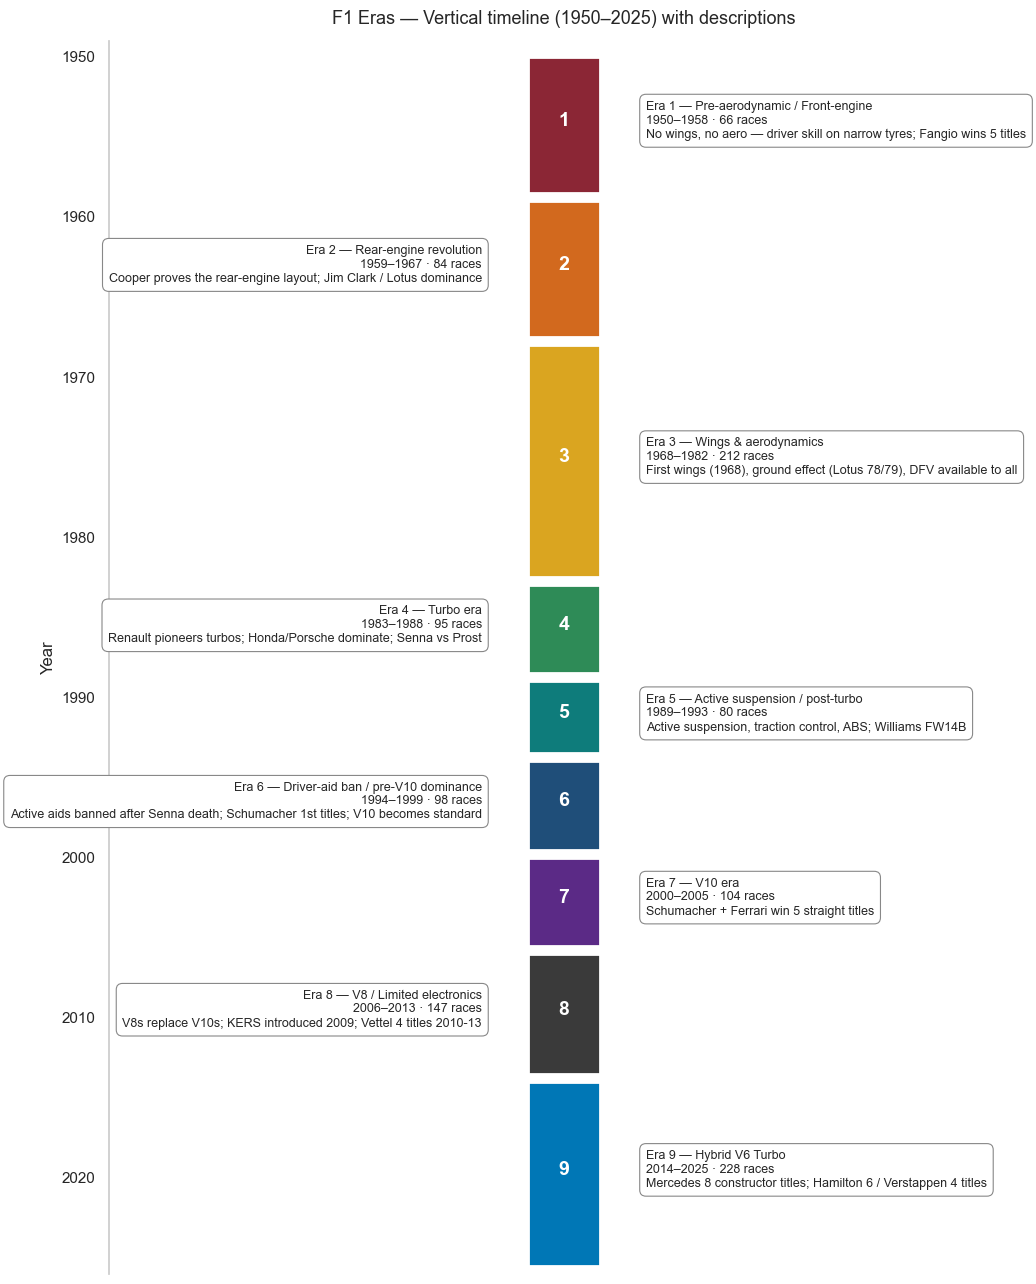

In [ ]:
# Chart 6.0 — F1 Eras vertical timeline
# Reverse-engineered from eras_df + era_check (the original cell was lost).
# Year on Y-axis (top→bottom = past→present), 9 colored bars on a center line,
# alternating-side description boxes with name, span, race count, key feature.

eras_with_meta = eras_df.merge(era_check[['era_id', 'races']],
                               on='era_id', how='left')

fig, ax = plt.subplots(figsize=(11, 13))

x_center  = 0.5
bar_width = 0.08

for _, era in eras_with_meta.iterrows():
    eid    = era['era_id']
    color  = ERA_COLORS[eid]
    y_top  = era['year_start']
    y_bot  = era['year_end']
    y_mid  = (y_top + y_bot) / 2

    # Era bar (vertical rectangle on center line)
    ax.add_patch(plt.Rectangle(
        (x_center - bar_width / 2, y_top),
        bar_width, y_bot - y_top + 0.5,
        facecolor=color, edgecolor='white', linewidth=2,
    ))

    # Era number badge (white bold text on the colored bar)
    ax.text(x_center, y_mid, str(eid),
            ha='center', va='center',
            fontsize=14, fontweight='bold', color='white')

    # Description box on alternating sides
    on_right = (eid % 2 == 1)
    x_text   = x_center + bar_width / 2 + 0.05 if on_right else x_center - bar_width / 2 - 0.05
    ha       = 'left' if on_right else 'right'

    text = (f'Era {eid} — {era["name_en"]}\n'
            f'{era["year_start"]}–{era["year_end"]} · {era["races"]} races\n'
            f'{era["key_feature"]}')

    ax.text(x_text, y_mid, text,
            ha=ha, va='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.5',
                      facecolor='white', edgecolor='#888', linewidth=0.8))

ax.set_xlim(0, 1)
ax.set_ylim(2026, 1949)            # inverted: year ascends downward
ax.set_xticks([])
ax.set_ylabel('Year')
ax.set_title('F1 Eras — Vertical timeline (1950–2025) with descriptions',
             fontsize=13, pad=12)
ax.grid(False)

for spine in ['top', 'right', 'bottom']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
show_and_save('6.0_eras_timeline.png')


**SQL equivalent**
```sql
-- The 9 F1 eras as a reference table joined with race counts
SELECT
    e.era_id, e.name_en, e.year_start, e.year_end,
    COUNT(ra.raceId) AS races,
    e.engine, e.dominant, e.key_feature
FROM   eras e
LEFT   JOIN races ra
       ON ra.year BETWEEN e.year_start AND e.year_end
       AND ra.name NOT LIKE '%Indianapolis%'
GROUP  BY e.era_id
ORDER  BY e.era_id;
```

In [ ]:
# Step 3 — quick demo: now we can ask "who won the most races in each era?"
# This is exactly the same kind of merge we will use for every later "per-era" question.
wins_per_era = (
    results[results['positionOrder'] == 1]
    .merge(races[['raceId', 'era_id']], on='raceId')
    .merge(constructors[['constructorId', 'name']].rename(columns={'name': 'team'}), on='constructorId')
    .groupby(['era_id', 'team'])
    .size()
    .reset_index(name='wins')
)

# Top team per era
top_team_per_era = (wins_per_era
    .sort_values(['era_id', 'wins'], ascending=[True, False])
    .groupby('era_id')
    .head(1)
    .merge(eras_df[['era_id', 'name_en', 'year_start', 'year_end']], on='era_id'))

print('Most-winning team in each era:')
print(top_team_per_era[['era_id', 'name_en', 'year_start', 'year_end', 'team', 'wins']]
      .to_string(index=False))


Most-winning team in each era:
 era_id                            name_en  year_start  year_end         team  wins
      1     Pre-aerodynamic / Front-engine        1950      1958      Ferrari    28
      2             Rear-engine revolution        1959      1967 Lotus-Climax    22
      3               Wings & aerodynamics        1968      1982      Ferrari    43
      4                          Turbo era        1983      1988      McLaren    41
      5     Active suspension / post-turbo        1989      1993      McLaren    34
      6 Driver-aid ban / pre-V10 dominance        1994      1999     Williams    32
      7                            V10 era        2000      2005      Ferrari    58
      8           V8 / Limited electronics        2006      2013     Red Bull    47
      9                    Hybrid V6 Turbo        2014      2025     Mercedes   116


---
## Era 1 deep-dive — Pre-aerodynamic / Front-engine (1950–1958)

### What defined this era
- **First F1 World Championship**: 1950 — only 7 European rounds (we exclude the Indianapolis 500, which was nominally part of the championship but a separate American oval race)
- **Cars**: front-engine layout, 1.5 L supercharged *or* 4.5 L naturally aspirated engines
- **No wings, no aero, no slicks** — driver skill on narrow tyres was decisive
- **Constructors' Championship**: introduced only in **1958** (the last year of this era). For 1950–1957 there was no formal team title — we therefore rank teams by average finishing position and total wins, not by titles

### Defining drivers and their World Championship years
| Driver | Titles | Seasons (constructor) |
|---|---|---|
| **Juan Manuel Fangio** | 5 | 1951 · Alfa Romeo  ·  1954 · Maserati → Mercedes (mid-season switch)  ·  1955 · Mercedes  ·  1956 · Ferrari  ·  1957 · Maserati  →  **4 different constructors** |
| **Alberto Ascari** | 2 | 1952 · Ferrari  ·  1953 · Ferrari |
| **Giuseppe Farina** | 1 | 1950 · Alfa Romeo — first F1 World Champion |
| **Mike Hawthorn** | 1 | 1958 · Ferrari — first British World Champion |

### Key historical events
- **Le Mans disaster (June 1955)** — 84 spectators killed; Mercedes withdrew from motorsport for 35 years
- **Mille Miglia banned (1957)** after a fatal accident
- **First Constructors' Champion (1958)** — Vanwall (UK)


### Era 1 — Top 10 drivers by win rate (chart 6.1)

Era 1 (1950–1958) — Top 10 drivers by win rate (min 5 starts):
     driver win_rate  wins  podiums  starts  titles                  title_years
  Fangio J.    41.4%    24       35      58       5 1951, 1954, 1955, 1956, 1957
  Ascari A.    37.1%    13       17      35       2                   1952, 1953
  Brooks T.    22.2%     4        5      18       0                             
    Moss S.    20.4%    10       16      49       0                             
  Farina N.    13.5%     5       20      37       1                         1950
 Fagioli L.    12.5%     1        6       8       0                             
 Collins P.     8.1%     3        9      37       0                             
González J.     7.1%     2       15      28       0                             
Hawthorn M.     6.2%     3       18      48       1                         1958
 Taruffi P.     5.6%     1        5      18       0                             


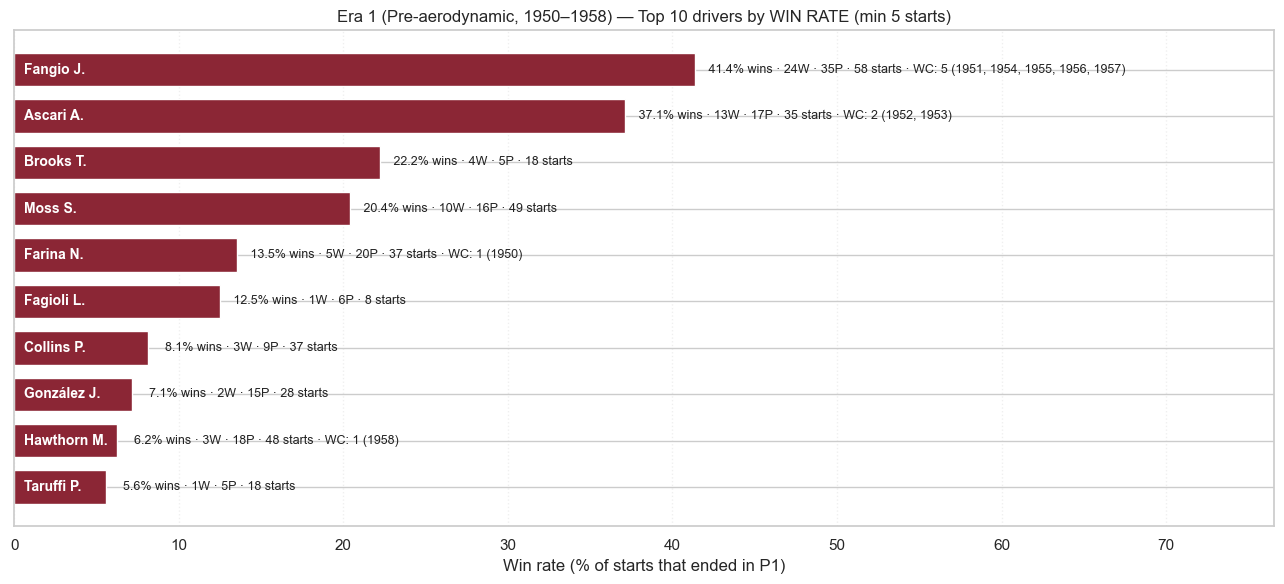

In [ ]:
# Era 1 — Top 10 DRIVERS by WIN RATE (1950–1958)
# Why win rate, not avg finishing position?  In 1950s F1, retirement rates
# were 50–70 % per race, so avg `positionOrder` (which includes DNFs) is
# dominated by reliability noise. Win rate isolates "how dominant when
# they raced" — the metric that actually answers "who was best in this era?"
ERA_ID = 1
y_start, y_end = (eras_df.loc[eras_df['era_id'] == ERA_ID,
                              ['year_start', 'year_end']].iloc[0])

# 1) all race results that fall inside Era 1
era1_results = (
    results.merge(races[['raceId', 'year', 'era_id']], on='raceId')
    .query('era_id == @ERA_ID')
)

# 2) WC titles per driver in this era
last_race_per_year = (races.assign(date=lambda d: pd.to_datetime(d['date']))
                      .sort_values('date')
                      .groupby('year').last().reset_index()[['year', 'raceId']])

champ = (standings.merge(last_race_per_year, on='raceId')
         .merge(races[['raceId', 'era_id']], on='raceId')
         .query('era_id == @ERA_ID and position == 1')[['driverId', 'year']])

titles_count = champ.groupby('driverId').size().to_dict()
titles_years = (champ.groupby('driverId')['year']
                .agg(lambda s: ', '.join(map(str, sorted(s)))).to_dict())

# 3) per-driver aggregate
era1_drv = (era1_results.groupby('driverId')
            .agg(starts=('raceId', 'count'),
                 wins=('positionOrder', lambda x: (x == 1).sum()),
                 podiums=('positionOrder', lambda x: (x <= 3).sum()))
            .reset_index()
            .merge(drivers[['driverId', 'forename', 'surname']], on='driverId'))

era1_drv['driver']      = era1_drv['surname'] + ' ' + era1_drv['forename'].str[0] + '.'
era1_drv['win_rate']    = era1_drv['wins']    / era1_drv['starts']
era1_drv['podium_rate'] = era1_drv['podiums'] / era1_drv['starts']
era1_drv['titles']      = era1_drv['driverId'].map(titles_count).fillna(0).astype(int)
era1_drv['title_years'] = era1_drv['driverId'].map(titles_years).fillna('')

# 4) Top 10 with ≥ 5 starts, ranked by win_rate DESC (best first)
top_drv = (era1_drv[era1_drv['starts'] >= 5]
           .sort_values('win_rate', ascending=False)
           .head(10).reset_index(drop=True))

print(f'Era 1 ({y_start}–{y_end}) — Top 10 drivers by win rate (min 5 starts):')
print(top_drv[['driver', 'win_rate', 'wins', 'podiums', 'starts',
               'titles', 'title_years']]
      .assign(win_rate=lambda d: (d['win_rate'] * 100).round(1).astype(str) + '%')
      .to_string(index=False))

# 5) Chart — bar = win rate (%); labels include podium rate, titles, span
fig, ax = plt.subplots(figsize=(13, 6))
era_color = ERA_COLORS[ERA_ID]
ax.barh(range(len(top_drv)), top_drv['win_rate'] * 100,
        color=era_color, edgecolor='white', height=0.72)

for i, row in enumerate(top_drv.itertuples()):
    ax.text(0.6, i, row.driver,                                 # name inside bar
            va='center', ha='left', fontsize=10,
            color='white', fontweight='bold')

    title_marker = (f' · WC: {row.titles} ({row.title_years})'
                    if row.titles > 0 else '')
    ax.text(row.win_rate * 100 + 0.6, i,                        # stats outside bar
            f'{row.win_rate*100:5.1f}% wins · '
            f'{row.wins}W · {row.podiums}P · {row.starts} starts{title_marker}',
            va='center', ha='left', fontsize=9, color='#222')

ax.set_yticks(range(len(top_drv)))
ax.set_yticklabels(['' for _ in range(len(top_drv))])
ax.invert_yaxis()                                                # best at top
ax.set_xlim(0, top_drv['win_rate'].max() * 100 * 1.85)
ax.set_xlabel('Win rate (% of starts that ended in P1)')
ax.set_ylabel('')
ax.set_title(f'Era 1 (Pre-aerodynamic, {y_start}–{y_end}) — '
             f'Top 10 drivers by WIN RATE (min 5 starts)')
ax.grid(axis='x', linestyle=':', alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
show_and_save('6.1_era1_top_drivers.png')


**SQL equivalent**
```sql
-- Top drivers in Era 1 by win rate (= wins / starts), min 5 starts
SELECT
    d.surname || ' ' || SUBSTR(d.forename, 1, 1) || '.'   AS driver,
    COUNT(*)                                              AS starts,
    SUM(CASE WHEN r.positionOrder = 1 THEN 1 ELSE 0 END)  AS wins,
    SUM(CASE WHEN r.positionOrder <= 3 THEN 1 ELSE 0 END) AS podiums,
    ROUND(100.0 * SUM(CASE WHEN r.positionOrder = 1 THEN 1 ELSE 0 END)
                / COUNT(*), 1)                            AS win_rate_pct
FROM   results        r
JOIN   races          ra ON r.raceId        = ra.raceId
JOIN   drivers        d  ON r.driverId      = d.driverId
JOIN   eras           e  ON ra.year BETWEEN e.year_start AND e.year_end
WHERE  e.era_id = 1
  AND  ra.name NOT LIKE '%Indianapolis%'    -- Indy 500 excluded
GROUP  BY r.driverId
HAVING COUNT(*) >= 5
ORDER  BY win_rate_pct DESC, wins DESC
LIMIT  10;
```

### Era 1 — Wins per constructor per season (chart 6.2)

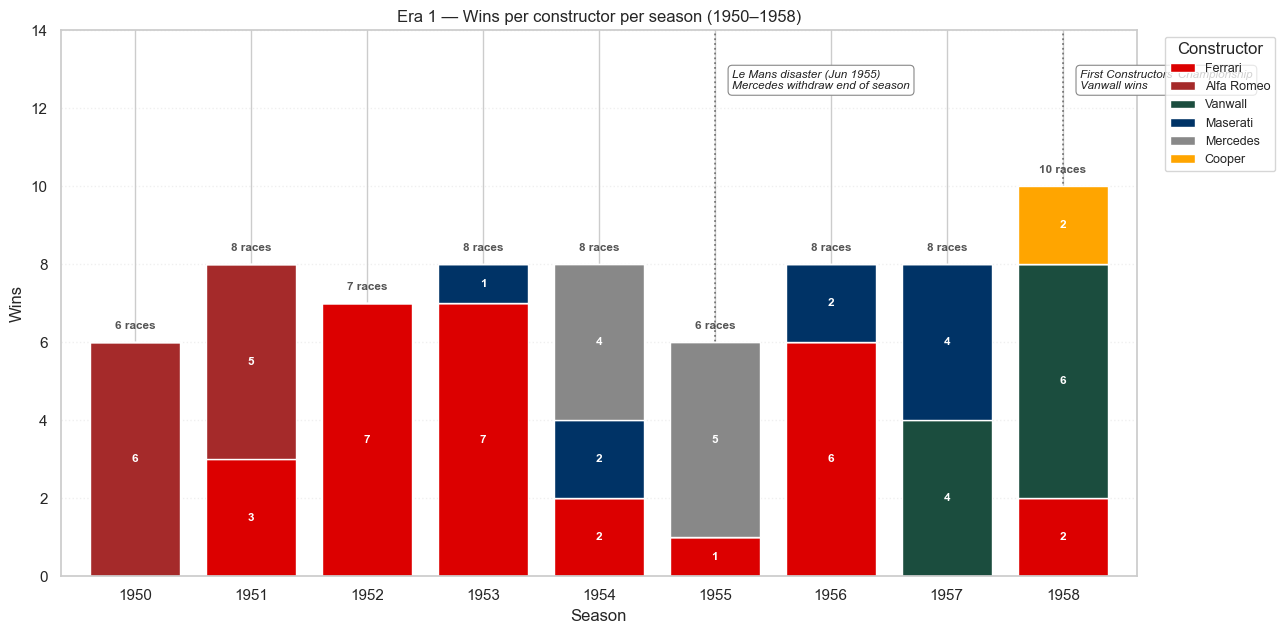

Most-winning constructor per season (Era 1):
        top_team  wins  races
year                         
1950  Alfa Romeo     6      6
1951  Alfa Romeo     5      8
1952     Ferrari     7      7
1953     Ferrari     7      8
1954    Mercedes     4      8
1955    Mercedes     5      6
1956     Ferrari     6      8
1957     Vanwall     4      8
1958     Vanwall     6     10


In [ ]:
# Era 1 — Wins per constructor per season (1950–1958), with event annotations
# Replaces the previous "top teams by avg position" chart.  This tells the
# real *narrative* of the decade: who was winning when, and how the major
# events (Le Mans 1955 → Mercedes withdrawal; first Constructors' title 1958)
# reshape the picture.

era1_winners = (era1_results.query('positionOrder == 1')
                .merge(constructors[['constructorId', 'name']],
                       on='constructorId')
                .rename(columns={'name': 'team'}))

wins_pivot = (era1_winners.groupby(['year', 'team']).size()
              .unstack(fill_value=0))

# Order columns: dominant teams (most total wins) first → they sit at the
# bottom of each stacked bar where the eye lands first.
team_order = wins_pivot.sum().sort_values(ascending=False).index.tolist()
wins_pivot = wins_pivot[team_order]

# Iconic colors where they exist; a fallback palette for the rest
ICONIC = {
    'Alfa Romeo': '#A52A2A',   # brick red
    'Ferrari':    '#DC0000',   # F1 Ferrari red
    'Maserati':   '#003366',   # blue
    'Mercedes':   '#888888',   # silver
    'Vanwall':    '#1B4D3E',   # British racing green
    'Cooper':     '#FFA500',
    'Cooper-Climax': '#FFA500',
    'BRM':        '#006400',
    'Lancia':     '#8B4513',
}
fallback = iter(['#5B2A86', '#0E7C7B', '#D2691E', '#3A3A3A', '#0077B6',
                 '#7F00FF', '#A0522D', '#708090', '#B22222'])
colors = [ICONIC.get(t, next(fallback, '#999')) for t in team_order]

# Plot
fig, ax = plt.subplots(figsize=(13, 6.5))
wins_pivot.plot(kind='bar', stacked=True, ax=ax, color=colors,
                edgecolor='white', width=0.78, zorder=2)

# Headroom for annotation labels above the tallest bar
top_y = wins_pivot.sum(axis=1).max()
ax.set_ylim(0, top_y * 1.40)

# Vertical event lines + label boxes
years_index = list(wins_pivot.index)
events = [
    (1955, 'Le Mans disaster (Jun 1955)\nMercedes withdraw end of season'),
    (1958, "First Constructors\u2019 Championship\nVanwall wins"),
]
for year, text in events:
    if year in years_index:
        x = years_index.index(year)
        ax.axvline(x, color='#333', linestyle=':',
                   alpha=0.6, linewidth=1.3, zorder=1)
        ax.text(x + 0.15, top_y * 1.30, text,
                fontsize=8.5, va='top', ha='left',
                style='italic', color='#222',
                bbox=dict(boxstyle='round,pad=0.35',
                          facecolor='white',
                          edgecolor='#888', linewidth=0.8))

# 1) Win-count INSIDE each segment — now ALL segments (>= 1 win)
# 2) Total race count ABOVE each bar
for season_idx, (year, row) in enumerate(wins_pivot.iterrows()):
    cum = 0
    for team, n_wins in row.items():
        if n_wins >= 1:
            ax.text(season_idx, cum + n_wins / 2, str(int(n_wins)),
                    ha='center', va='center',
                    fontsize=8.5, color='white', fontweight='bold')
        cum += n_wins
    total = int(row.sum())
    ax.text(season_idx, total + top_y * 0.03,
            f'{total} race{"s" if total != 1 else ""}',
            ha='center', va='bottom',
            fontsize=8.5, color='#555', fontweight='bold')

ax.set_title('Era 1 — Wins per constructor per season (1950–1958)',
             fontsize=12)
ax.set_xlabel('Season')
ax.set_ylabel('Wins')
ax.legend(title='Constructor', loc='upper left',
          bbox_to_anchor=(1.02, 1.0), frameon=True, fontsize=9)
ax.grid(axis='y', linestyle=':', alpha=0.3)
ax.set_axisbelow(True)
plt.xticks(rotation=0)
plt.tight_layout()
show_and_save('6.2_era1_wins_per_team.png')

# Quick sanity print: champion constructor per season (most wins; 1958 was the
# first formal Constructors' Championship — Vanwall)
season_top = (wins_pivot.idxmax(axis=1).rename('top_team')
              .to_frame()
              .assign(wins=wins_pivot.max(axis=1),
                      races=wins_pivot.sum(axis=1)))
print('Most-winning constructor per season (Era 1):')
print(season_top.to_string())


**SQL equivalent**
```sql
-- Wins per constructor per season for Era 1
SELECT
    ra.year   AS season,
    c.name    AS team,
    COUNT(*)  AS wins
FROM   results        r
JOIN   races          ra ON r.raceId        = ra.raceId
JOIN   constructors   c  ON r.constructorId = c.constructorId
JOIN   eras           e  ON ra.year BETWEEN e.year_start AND e.year_end
WHERE  r.positionOrder = 1
  AND  e.era_id        = 1
  AND  ra.name NOT LIKE '%Indianapolis%'
GROUP  BY ra.year, c.name
ORDER  BY ra.year, wins DESC;
```

---
## Eras 2–9 — same analysis applied through reusable helpers

The Era 1 deep-dive established the pattern (top drivers by win rate · wins
per constructor per season). Repeating it 8 more times by hand would be
copy-paste hell, so we extract the logic into two helpers:

- `plot_era_top_drivers(era_id, top_n=10, min_starts=5)`
- `plot_era_wins_per_team(era_id)`

Per-era event annotations live in a single `ERA_EVENTS` dict, so we can
edit them in one place and every chart picks up the change automatically.

In [ ]:
# Reusable helpers for per-era deep-dives
# ─────────────────────────────────────────────────────────────────────────

# Per-era historical event annotations (year, label) — one source of truth
ERA_EVENTS = {
    1: [(1955, 'Le Mans disaster (Jun 1955)\nMercedes withdraw end of season'),
        (1958, "First Constructors' Championship\nVanwall wins")],
    2: [(1961, '1.5 L formula introduced'),
        (1962, 'Lotus 25 — first monocoque chassis'),
        (1966, '3.0 L formula introduced')],
    3: [(1968, 'Wings appear'),
        (1977, 'Lotus 78 ground effect'),
        (1982, 'Villeneuve & Paletti die')],
    4: [(1984, 'Lauda beats Prost\nby 0.5 points'),
        (1988, 'McLaren-Honda:\n15 of 16 wins')],
    5: [(1992, 'Williams FW14B\nactive suspension')],
    6: [(1994, '1 May: Senna and Ratzenberger\nkilled at Imola'),
        (1996, 'Schumacher → Ferrari')],
    7: [(2002, 'Schumacher 11 wins of 17'),
        (2004, 'Schumacher 13 of 18 — 5th title')],
    8: [(2009, 'Brawn fairytale\nKERS introduced'),
        (2011, 'DRS introduced')],
    9: [(2018, 'Halo introduced'),
        (2021, 'Verstappen 1st title'),
        (2022, 'Ground-effect cars return')],
}

# Iconic team colors. Unknown teams fall through to the deterministic fallback.
ICONIC_TEAM_COLORS = {
    'Alfa Romeo':'#A52A2A', 'Ferrari':'#DC0000', 'Maserati':'#003366',
    'Mercedes':'#888888', 'Vanwall':'#1B4D3E',
    'Cooper':'#FFA500', 'Cooper-Climax':'#FFA500', 'Cooper-Maserati':'#FFA500',
    'BRM':'#006400', 'Lancia':'#8B4513',
    'Lotus':'#1B5E20', 'Lotus-Climax':'#1B5E20', 'Lotus-BRM':'#1B5E20',
    'Lotus-Ford':'#1B5E20', 'Team Lotus':'#1B5E20',
    'Brabham':'#FFC107', 'Brabham-Repco':'#FFC107', 'Brabham-BMW':'#FFC107',
    'Brabham-Ford':'#FFC107', 'Brabham-Alfa Romeo':'#FFC107',
    'Tyrrell':'#1F4E79', 'Tyrrell-Ford':'#1F4E79',
    'March':'#5B2A86', 'March-Ford':'#5B2A86',
    'Matra':'#0066CC', 'Matra-Ford':'#0066CC',
    'McLaren':'#FF8700', 'McLaren-Ford':'#FF8700', 'McLaren-TAG':'#FF8700',
    'McLaren-Honda':'#FF8700', 'McLaren-Mercedes':'#FF8700',
    'Williams':'#0099FF', 'Williams-Ford':'#0099FF', 'Williams-Honda':'#0099FF',
    'Williams-Renault':'#0099FF', 'Williams-BMW':'#0099FF', 'Williams-Mercedes':'#0099FF',
    'Renault':'#FFD700',
    'Benetton':'#0066CC', 'Benetton-Ford':'#0066CC', 'Benetton-Renault':'#0066CC',
    'Jordan':'#FFB300', 'Jordan-Honda':'#FFB300', 'Jordan-Mugen-Honda':'#FFB300',
    'Brawn':'#80FF00', 'Honda':'#E60012',
    'Red Bull':'#1E41FF', 'Toro Rosso':'#475F8B', 'AlphaTauri':'#2B4562',
    'Sauber':'#52E252', 'Haas F1 Team':'#9C9C9C',
    'Force India':'#FF80C7', 'Racing Point':'#F596C8',
    'Aston Martin':'#006F62', 'Alpine F1 Team':'#0090FF',
    'BAR':'#003366', 'BMW Sauber':'#003BFF',
    'Stewart':'#003366', 'Arrows':'#FFA500', 'Prost':'#003366',
    'Shadow':'#222222', 'Hesketh':'#FF1493', 'Ligier':'#0099FF',
    'Wolf':'#222222', 'Ensign':'#999999', 'Surtees':'#DC0000',
    'ATS':'#5B2A86', 'Fittipaldi':'#FFD700',
    'Toleman':'#0E7C7B', 'Spirit':'#888888',
    'Minardi':'#000000', 'Footwork':'#FFA500', 'Larrousse':'#5B2A86',
}
_FALLBACK = ['#5B2A86', '#0E7C7B', '#D2691E', '#3A3A3A', '#0077B6',
             '#7F00FF', '#A0522D', '#708090', '#B22222', '#4B0082',
             '#556B2F', '#2F4F4F', '#8B0000', '#9932CC', '#FF1493']


def _team_palette(team_order):
    """Return a stable color list for the given team order."""
    fb = iter(_FALLBACK)
    return [ICONIC_TEAM_COLORS.get(t, next(fb, '#999')) for t in team_order]


def _era_results(era_id):
    """All race results inside `era_id` (Indy 500 already stripped at source)."""
    return (results.merge(races[['raceId', 'year', 'era_id']], on='raceId')
                   .query('era_id == @era_id'))


def _era_titles(era_id):
    """Return (titles_count, titles_years) dicts keyed by driverId for `era_id`."""
    last_race = (races.assign(date=lambda d: pd.to_datetime(d['date']))
                 .sort_values('date')
                 .groupby('year').last().reset_index()[['year', 'raceId']])
    champ = (standings.merge(last_race, on='raceId')
             .merge(races[['raceId', 'era_id']], on='raceId')
             .query('era_id == @era_id and position == 1')[['driverId', 'year']])
    counts = champ.groupby('driverId').size().to_dict()
    years  = (champ.groupby('driverId')['year']
              .agg(lambda s: ', '.join(map(str, sorted(s)))).to_dict())
    return counts, years


def plot_era_top_drivers(era_id, top_n=10, min_starts=5):
    """Top-N drivers in `era_id` by win rate (= wins / starts), min `min_starts` starts."""
    era_row = eras_df.loc[eras_df['era_id'] == era_id].iloc[0]
    name_en       = era_row['name_en']
    y_start, y_end = era_row['year_start'], era_row['year_end']

    er = _era_results(era_id)
    counts, years_dict = _era_titles(era_id)

    drv = (er.groupby('driverId')
           .agg(starts=('raceId', 'count'),
                wins=('positionOrder', lambda x: (x == 1).sum()),
                podiums=('positionOrder', lambda x: (x <= 3).sum()))
           .reset_index()
           .merge(drivers[['driverId', 'forename', 'surname']], on='driverId'))

    drv['driver']      = drv['surname'] + ' ' + drv['forename'].str[0] + '.'
    drv['win_rate']    = drv['wins']    / drv['starts']
    drv['titles']      = drv['driverId'].map(counts).fillna(0).astype(int)
    drv['title_years'] = drv['driverId'].map(years_dict).fillna('')

    top = (drv[drv['starts'] >= min_starts]
           .sort_values('win_rate', ascending=False)
           .head(top_n).reset_index(drop=True))

    print(f'Era {era_id} ({name_en}, {y_start}–{y_end}) — '
          f'Top {top_n} drivers by win rate (min {min_starts} starts):')
    print(top[['driver', 'win_rate', 'wins', 'podiums', 'starts',
               'titles', 'title_years']]
          .assign(win_rate=lambda d: (d['win_rate']*100).round(1).astype(str) + '%')
          .to_string(index=False))

    fig, ax = plt.subplots(figsize=(13, 0.55 * top_n + 1.3))
    ax.barh(range(len(top)), top['win_rate'] * 100,
            color=ERA_COLORS[era_id], edgecolor='white', height=0.72)

    for i, row in enumerate(top.itertuples()):
        ax.text(0.6, i, row.driver, va='center', ha='left',
                fontsize=10, color='white', fontweight='bold')
        title_marker = (f' · WC: {row.titles} ({row.title_years})'
                        if row.titles > 0 else '')
        ax.text(row.win_rate * 100 + 0.6, i,
                f'{row.win_rate*100:5.1f}% wins · '
                f'{row.wins}W · {row.podiums}P · {row.starts} starts{title_marker}',
                va='center', ha='left', fontsize=9, color='#222')

    ax.set_yticks(range(len(top))); ax.set_yticklabels([''] * len(top))
    ax.invert_yaxis()
    ax.set_xlim(0, max(top['win_rate'].max() * 100 * 1.85, 5))
    ax.set_xlabel('Win rate (% of starts that ended in P1)')
    ax.set_title(f'Era {era_id} ({name_en}, {y_start}–{y_end}) — '
                 f'Top {top_n} drivers by WIN RATE (min {min_starts} starts)')
    ax.grid(axis='x', linestyle=':', alpha=0.3); ax.set_axisbelow(True)
    plt.tight_layout()
    show_and_save(f'6.1_era{era_id}_top_drivers.png')


def plot_era_wins_per_team(era_id):
    """Stacked bar of wins per constructor per season for `era_id`, with annotations."""
    era_row = eras_df.loc[eras_df['era_id'] == era_id].iloc[0]
    name_en       = era_row['name_en']
    y_start, y_end = era_row['year_start'], era_row['year_end']

    er = _era_results(era_id)
    winners = (er.query('positionOrder == 1')
               .merge(constructors[['constructorId', 'name']], on='constructorId')
               .rename(columns={'name': 'team'}))
    pivot = (winners.groupby(['year', 'team']).size().unstack(fill_value=0))
    team_order = pivot.sum().sort_values(ascending=False).index.tolist()
    pivot = pivot[team_order]
    colors = _team_palette(team_order)

    n_seasons = len(pivot.index)
    fig, ax = plt.subplots(figsize=(max(8, n_seasons * 0.95 + 3), 6.5))
    pivot.plot(kind='bar', stacked=True, ax=ax, color=colors,
               edgecolor='white', width=0.78, zorder=2)

    top_y = pivot.sum(axis=1).max()
    ax.set_ylim(0, top_y * 1.40)

    years_index = list(pivot.index)
    for year, text in ERA_EVENTS.get(era_id, []):
        if year in years_index:
            x = years_index.index(year)
            ax.axvline(x, color='#333', linestyle=':', alpha=0.6,
                       linewidth=1.3, zorder=1)
            ax.text(x + 0.15, top_y * 1.30, text,
                    fontsize=8.5, va='top', ha='left', style='italic', color='#222',
                    bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                              edgecolor='#888', linewidth=0.8))

    for season_idx, (year, row) in enumerate(pivot.iterrows()):
        cum = 0
        for team, n_wins in row.items():
            if n_wins >= 1:
                ax.text(season_idx, cum + n_wins / 2, str(int(n_wins)),
                        ha='center', va='center',
                        fontsize=8.5, color='white', fontweight='bold')
            cum += n_wins
        total = int(row.sum())
        ax.text(season_idx, total + top_y * 0.03,
                f'{total} race{"s" if total != 1 else ""}',
                ha='center', va='bottom',
                fontsize=8.5, color='#555', fontweight='bold')

    ax.set_title(f'Era {era_id} ({name_en}) — Wins per constructor per season ({y_start}–{y_end})',
                 fontsize=12)
    ax.set_xlabel('Season'); ax.set_ylabel('Wins')
    ax.legend(title='Constructor', loc='upper left',
              bbox_to_anchor=(1.02, 1.0), frameon=True, fontsize=9)
    ax.grid(axis='y', linestyle=':', alpha=0.3); ax.set_axisbelow(True)
    plt.xticks(rotation=0)
    plt.tight_layout()
    show_and_save(f'6.2_era{era_id}_wins_per_team.png')


---
## Era 2 deep-dive — Rear-engine revolution (1959–1967)

### What defined this era
- Cooper proves the **rear-engine layout** in 1959 — by 1962 every front-engine car is gone
- Engine formulas: **2.5 L NA (1959–60)** → **1.5 L NA (1961–65)** → **3.0 L NA (1966–67)**
- 1962 — Lotus 25 introduces the **monocoque chassis** (Colin Chapman's revolution)
- Aero is still minimal; tyres become more specialized

### Defining drivers and their World Championship years
| Driver | Titles | Seasons (constructor) |
|---|---|---|
| **Jack Brabham** | 3 | 1959 · Cooper  ·  1960 · Cooper  ·  1966 · Brabham (his own team!) |
| **Jim Clark** | 2 | 1963 · Lotus  ·  1965 · Lotus |
| Phil Hill | 1 | 1961 · Ferrari — first American World Champion |
| Graham Hill | 1 | 1962 · BRM |
| John Surtees | 1 | 1964 · Ferrari — only champion on **both 2 and 4 wheels** |
| Denny Hulme | 1 | 1967 · Brabham |

### Key historical events
- **1959** — Cooper-Climax wins, rear-engine revolution begins
- **1961** — engine size halved to 1.5 L; Ferrari "sharknose" dominates
- **1962** — Lotus 25 monocoque chassis
- **1966** — engine size jumps to 3.0 L


### Era 2 — Top 10 drivers by win rate (chart 6.1)

Era 2 (Rear-engine revolution, 1959–1967) — Top 10 drivers by win rate (min 5 starts):
       driver win_rate  wins  podiums  starts  titles      title_years
     Clark J.    33.3%    24       31      72       2       1963, 1965
      Moss S.    25.0%     6        8      24       0                 
   Brabham J.    16.5%    13       25      79       3 1959, 1960, 1966
      Hill G.    12.2%    10       28      82       1             1962
 von Trips W.    11.1%     2        4      18       0                 
Scarfiotti L.    10.0%     1        1      10       0                 
   Surtees J.     9.0%     6       21      67       1             1964
    Brooks T.     8.7%     2        5      23       0                 
     Hulme D.     7.7%     2       12      26       1             1967
   Stewart J.     6.9%     2        8      29       0                 


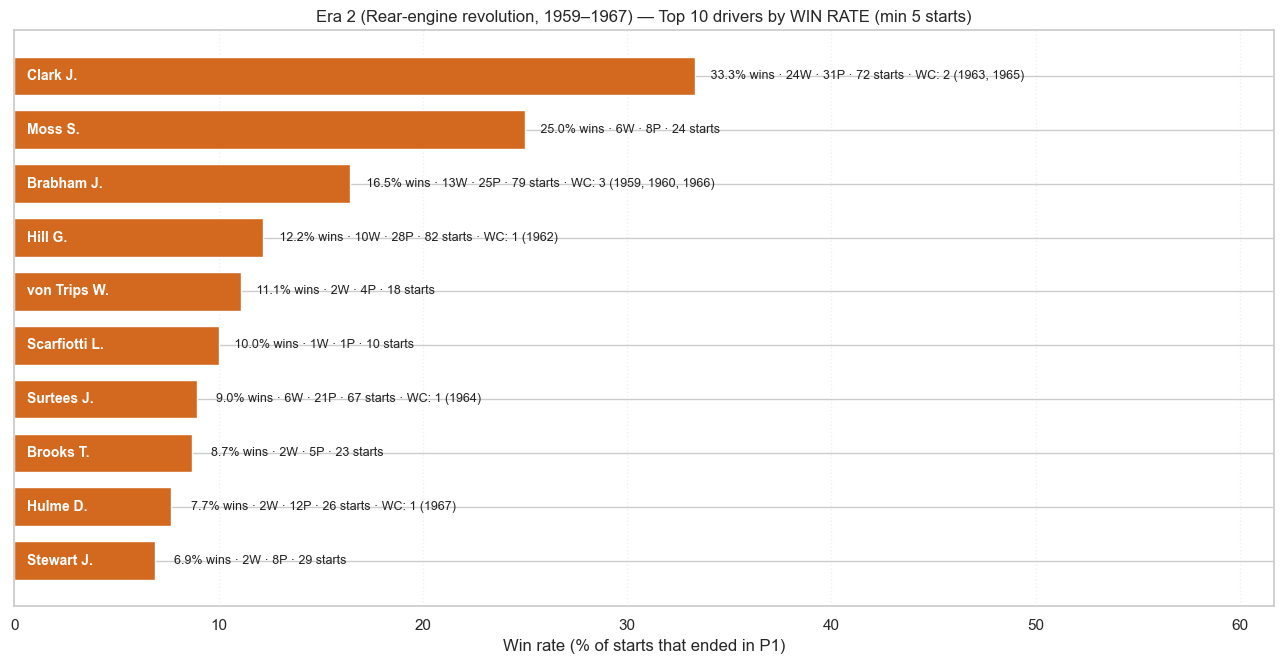

In [ ]:
plot_era_top_drivers(era_id=2)


### Era 2 — Wins per constructor per season (chart 6.2)

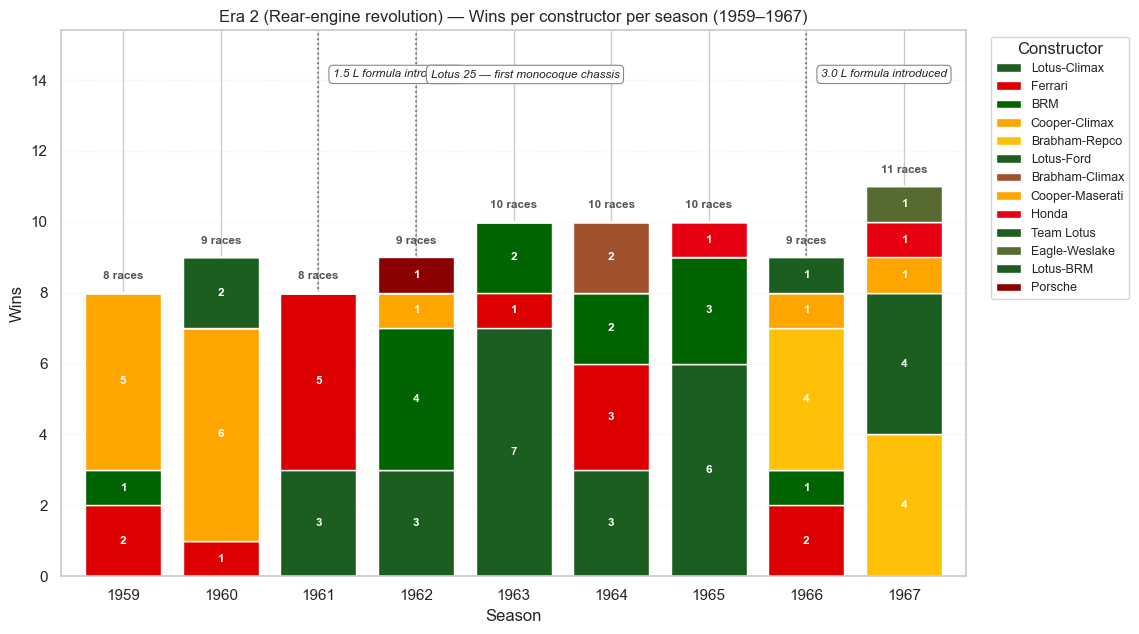

In [ ]:
plot_era_wins_per_team(era_id=2)


---
## Era 3 deep-dive — Wings & aerodynamics (1968–1982)

### What defined this era
- 1968 — wings appear on F1 cars (Ferrari, Brabham, Lotus all in the same season)
- 1977–1979 — **ground effect** (Lotus 78, then Lotus 79 dominates)
- The **Cosworth DFV V8** is sold to any team that pays — private constructors thrive
- 1981 — McLaren MP4/1: first **carbon-fibre monocoque**
- 1982 — tragic season: Villeneuve killed at Zolder, Paletti at Montreal

### Defining drivers — 11 different World Champions in 15 seasons
| Driver | Titles in Era 3 | Seasons (constructor) |
|---|---|---|
| Jackie Stewart | 3 | 1969 · Matra  ·  1971 · Tyrrell  ·  1973 · Tyrrell |
| Niki Lauda | 2 (Era 3) | 1975 · Ferrari  ·  1977 · Ferrari |
| Emerson Fittipaldi | 2 | 1972 · Lotus  ·  1974 · McLaren |
| Graham Hill | 1 (Era 3) | 1968 · Lotus |
| Jochen Rindt | 1 | 1970 · Lotus — **posthumous champion** (killed in qualifying at Monza) |
| James Hunt | 1 | 1976 · McLaren |
| Mario Andretti | 1 | 1978 · Lotus |
| Jody Scheckter | 1 | 1979 · Ferrari |
| Alan Jones | 1 | 1980 · Williams |
| Nelson Piquet | 1 (Era 3) | 1981 · Brabham |
| Keke Rosberg | 1 | 1982 · Williams — won the title with **only 1 win** |

### Key historical events
- **1968** — wings appear; Hill wins title with the Lotus 49B
- **1970** — Rindt's posthumous title
- **1977–1979** — Lotus 78/79 ground-effect dominance
- **1981** — McLaren MP4/1 introduces carbon-fibre monocoque
- **1982** — Villeneuve and Paletti die; Rosberg champion with 1 win

### Era 3 — Top 10 drivers by win rate (chart 6.1)

Era 3 (Wings & aerodynamics, 1968–1982) — Top 10 drivers by win rate (min 5 starts):
       driver win_rate  wins  podiums  starts  titles      title_years
   Stewart J.    35.2%    25       35      71       3 1969, 1971, 1973
     Rindt J.    18.8%     6       10      32       1             1970
     Lauda N.    14.7%    19       42     129       2       1975, 1977
     Jones A.    12.5%    12       24      96       1             1980
     Prost A.    11.4%     5       10      44       0                 
    Piquet N.    10.9%     7       15      64       1             1981
      Hunt J.    10.8%    10       23      93       1             1976
Fittipaldi E.     9.4%    14       35     149       2       1972, 1974
  Andretti M.     9.3%    12       19     129       1             1978
 Scheckter J.     8.8%    10       33     113       1             1979


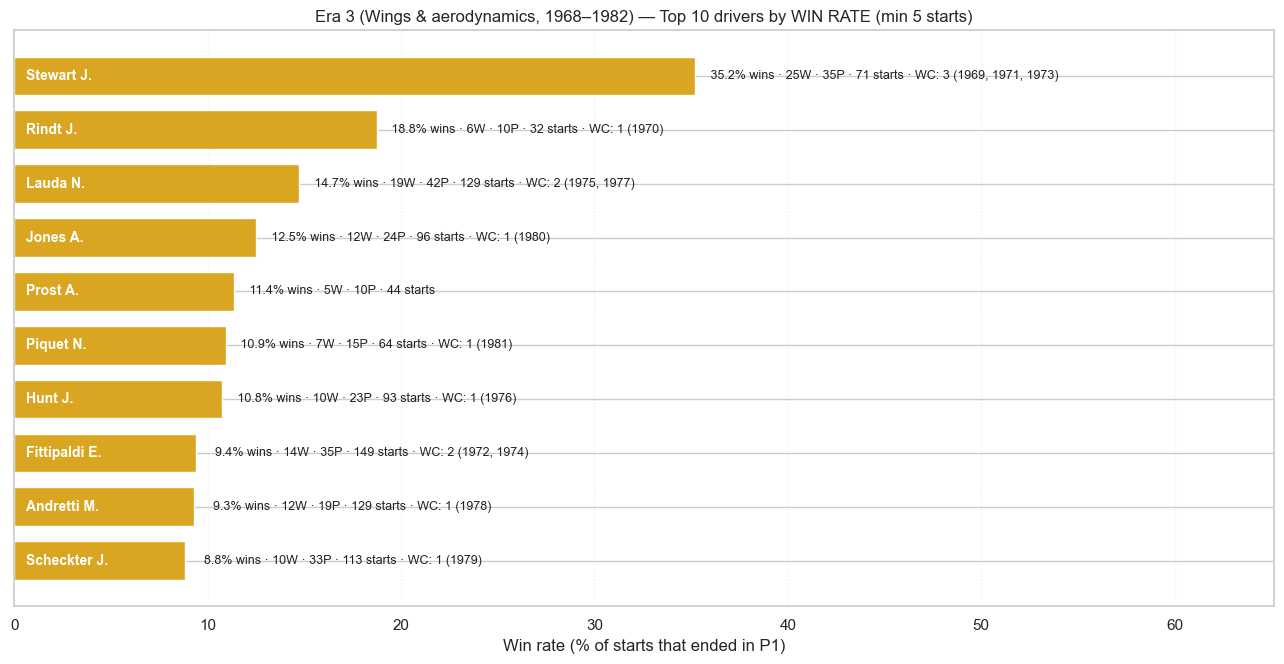

In [ ]:
plot_era_top_drivers(era_id=3)


### Era 3 — Wins per constructor per season (chart 6.2)

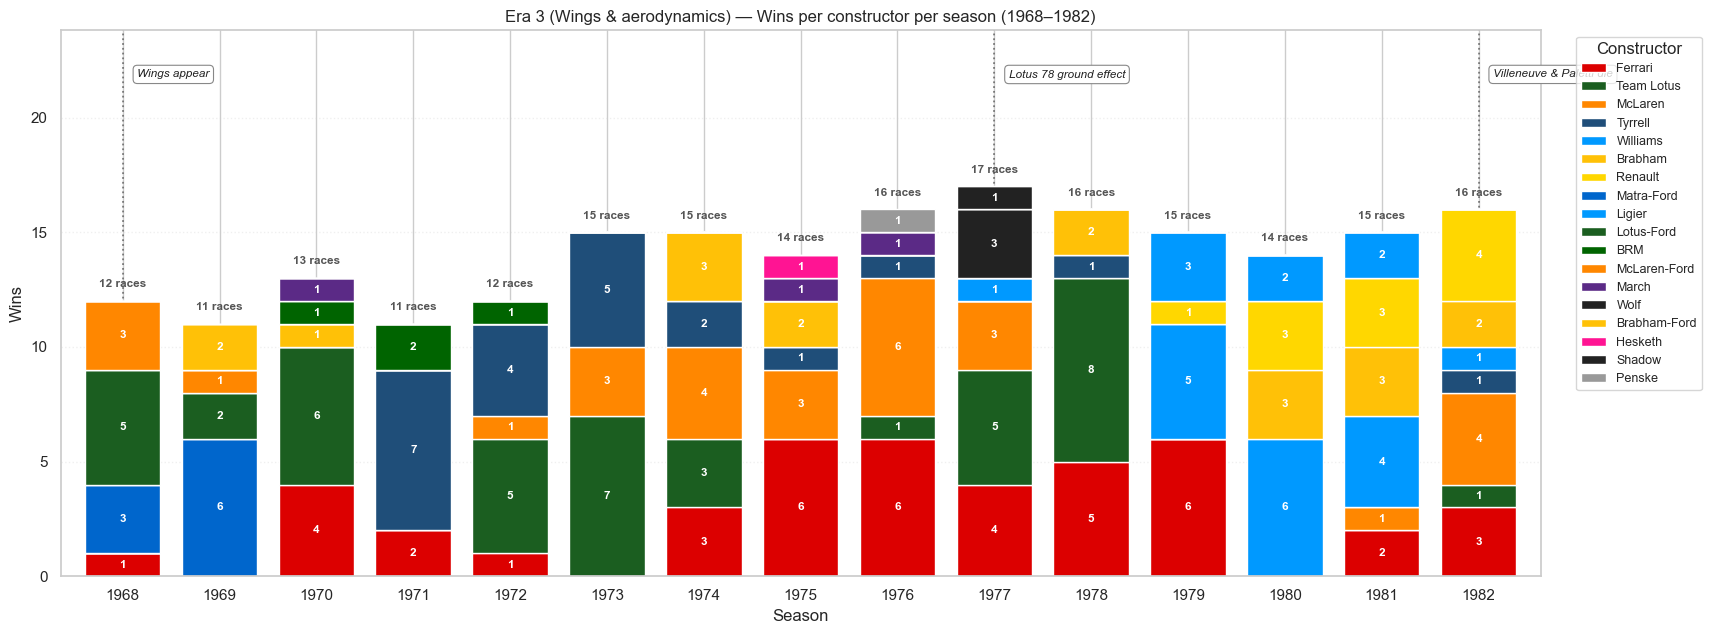

In [ ]:
plot_era_wins_per_team(era_id=3)


---
## Era 4 deep-dive — Turbo era (1983–1988)

### What defined this era
- 1.5 L turbo engines reach **~1300 hp in qualifying** trim — the most powerful F1 engines ever
- Renault pioneered turbos in 1977; by 1983 NA engines are extinct
- Honda, BMW, Porsche/TAG, Ferrari and Renault all build turbo F1 engines
- 1986 boost limit (4 bar) → 1988 limit (2.5 bar) → 1989 turbos banned outright

### Defining drivers
| Driver | Titles in Era 4 | Seasons (constructor) |
|---|---|---|
| Alain Prost | 2 (Era 4) | 1985 · McLaren-TAG  ·  1986 · McLaren-TAG |
| Nelson Piquet | 2 (Era 4) | 1983 · Brabham-BMW  ·  1987 · Williams-Honda |
| Niki Lauda | 1 (Era 4) | 1984 · McLaren-TAG — beat Prost by **0.5 points**, the closest title in F1 history |
| Ayrton Senna | 1 (Era 4) | 1988 · McLaren-Honda — **15 of 16 wins** |

### Key historical events
- **1983** — Brabham-BMW: first turbo title (Piquet)
- **1984** — Lauda beats Prost by 0.5 points
- **1986** — boost limit at 4 bar; turbos still ~1100 hp
- **1988** — McLaren-Honda's 15-of-16 season; turbo's swansong


### Era 4 — Top 10 drivers by win rate (chart 6.1)

Era 4 (Turbo era, 1983–1988) — Top 10 drivers by win rate (min 5 starts):
     driver win_rate  wins  podiums  starts  titles title_years
   Prost A.    31.6%    30       59      95       2  1985, 1986
   Senna A.    17.7%    14       36      79       1        1988
 Mansell N.    14.1%    13       24      92       0            
  Piquet N.    13.7%    13       38      95       2  1983, 1987
   Lauda N.    13.3%     6       12      45       1        1984
 Rosberg K.     6.3%     4       10      63       0            
  Watson J.     6.2%     1        3      16       0            
  Berger G.     5.9%     4       10      68       0            
Alboreto M.     4.2%     4       20      95       0            
  Arnoux R.     3.8%     3       11      79       0            


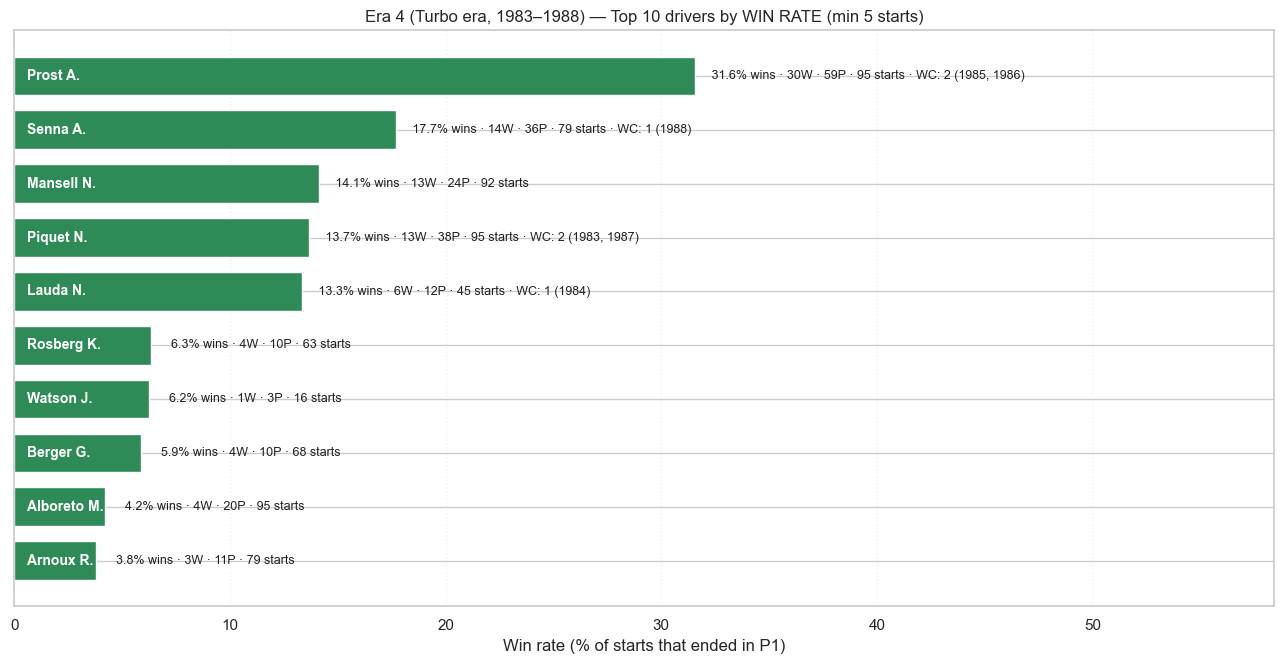

In [ ]:
plot_era_top_drivers(era_id=4)


### Era 4 — Wins per constructor per season (chart 6.2)

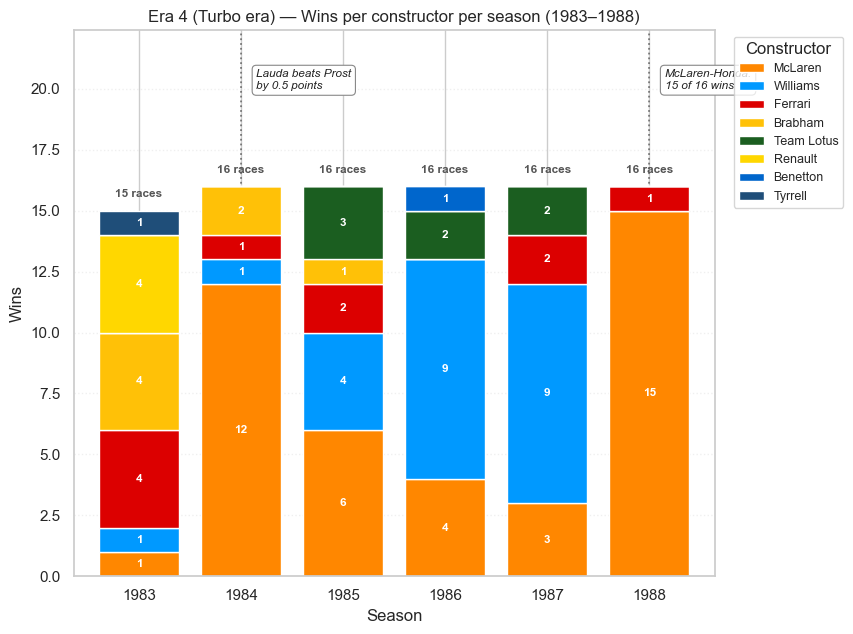

In [ ]:
plot_era_wins_per_team(era_id=4)


---
## Era 5 deep-dive — Active suspension / post-turbo (1989–1993)

### What defined this era
- 1989 turbo ban → return to **NA 3.5 L engines** (V8/V10/V12)
- Active suspension, traction control, ABS — F1's most computer-dominated period
- **Williams FW14B (1992)** — often cited as the most technologically advanced F1 car ever built
- Senna vs Prost rivalry continues at McLaren; Mansell + Williams arrive

### Defining drivers
| Driver | Titles in Era 5 | Seasons (constructor) |
|---|---|---|
| Ayrton Senna | 2 (Era 5) | 1990 · McLaren-Honda  ·  1991 · McLaren-Honda |
| Alain Prost | 2 (Era 5) | 1989 · McLaren-Honda  ·  1993 · Williams-Renault — his 4th and last title |
| Nigel Mansell | 1 | 1992 · Williams-Renault — dominant FW14B (9 wins) |

### Key historical events
- **1989** — turbos banned; 3.5 L NA formula
- **1990** — Senna vs Prost collision at Suzuka turn 1
- **1992** — Williams FW14B with active suspension wins 10 of 16
- **1993** — Prost's 4th and final title; all driver aids banned for 1994


### Era 5 — Top 10 drivers by win rate (chart 6.1)

Era 5 (Active suspension / post-turbo, 1989–1993) — Top 10 drivers by win rate (min 5 starts):
       driver win_rate  wins  podiums  starts  titles title_years
     Senna A.    33.8%    27       44      80       2  1990, 1991
   Mansell N.    27.0%    17       32      63       1        1992
     Prost A.    25.4%    16       37      63       2  1989, 1993
      Hill D.    12.5%     3       10      24       0            
    Piquet N.     6.2%     3        7      48       0            
Schumacher M.     5.3%     2       17      38       0            
    Berger G.     5.1%     4       22      79       0            
   Patrese R.     5.0%     4       26      80       0            
   Boutsen T.     4.1%     3        8      74       0            
   Nannini A.     3.3%     1        7      30       0            


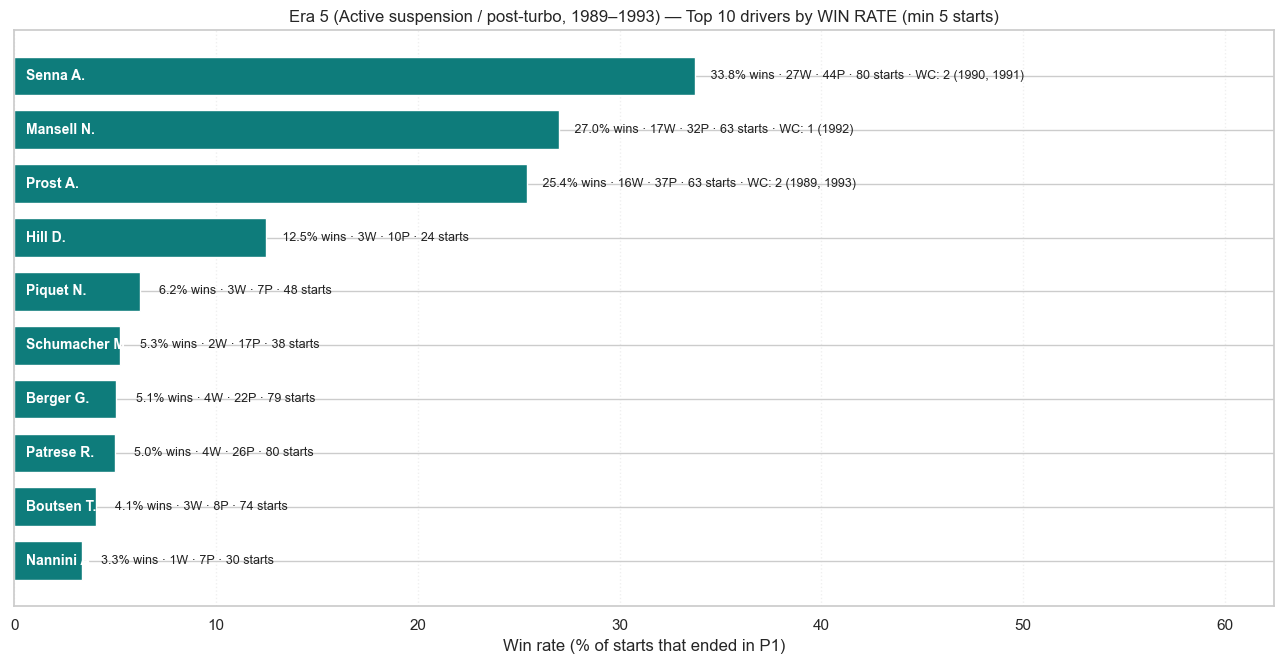

In [ ]:
plot_era_top_drivers(era_id=5)


### Era 5 — Wins per constructor per season (chart 6.2)

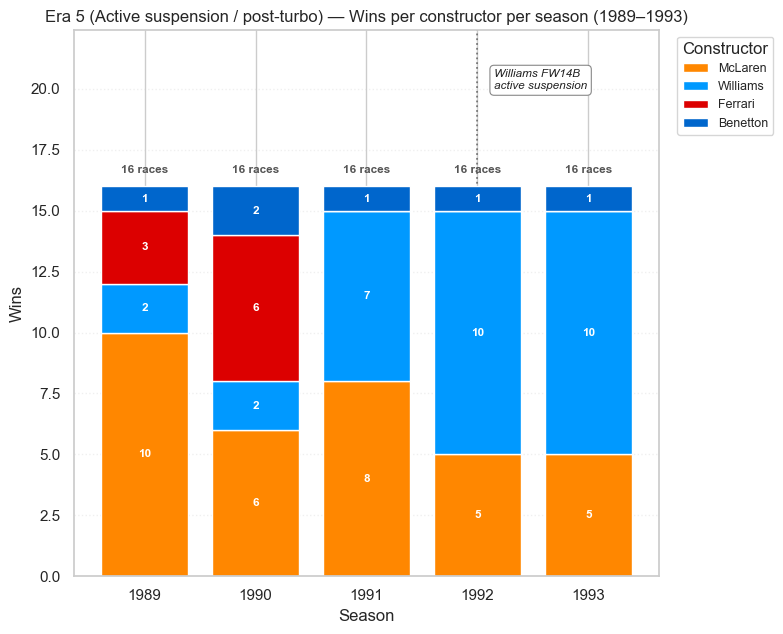

In [ ]:
plot_era_wins_per_team(era_id=5)


---
## Era 6 deep-dive — Driver-aid ban / pre-V10 dominance (1994–1999)

### What defined this era
- All electronic driver aids banned for 1994 — back to "raw" driving
- **1 May 1994** — Ayrton Senna and Roland Ratzenberger killed at Imola (one weekend)
- Schumacher's first 2 titles (1994 with Benetton, 1995 ditto)
- Williams reasserts itself in 1996–97; McLaren-Mercedes takes over 1998–99
- V10 engines become the de facto standard

### Defining drivers
| Driver | Titles | Seasons (constructor) |
|---|---|---|
| Michael Schumacher | 2 (Era 6) | 1994 · Benetton-Ford  ·  1995 · Benetton-Renault |
| Mika Häkkinen | 2 | 1998 · McLaren-Mercedes  ·  1999 · McLaren-Mercedes |
| Damon Hill | 1 | 1996 · Williams-Renault — son of Graham Hill (Eras 2 & 3) |
| Jacques Villeneuve | 1 | 1997 · Williams-Renault — son of Gilles Villeneuve (Era 3) |

### Key historical events
- **1 May 1994** — Senna & Ratzenberger killed at Imola
- **1994** — Schumacher–Hill collision at Adelaide decides the title
- **1996** — Schumacher → Ferrari, beginning the Era 7 rebuild
- **1998–99** — Hakkinen wins back-to-back for McLaren-Mercedes


### Era 6 — Top 10 drivers by win rate (chart 6.1)

Era 6 (Driver-aid ban / pre-V10 dominance, 1994–1999) — Top 10 drivers by win rate (min 5 starts):
       driver win_rate  wins  podiums  starts  titles title_years
Schumacher M.    36.7%    33       54      90       2  1994, 1995
      Hill D.    19.4%    19       32      98       1        1996
Villeneuve J.    16.9%    11       21      65       1        1997
   Mansell N.    16.7%     1        1       6       0            
  Häkkinen M.    14.6%    14       36      96       2  1998, 1999
 Coulthard D.     6.7%     6       30      90       0            
    Irvine E.     4.2%     4       24      95       0            
    Berger G.     3.2%     2       16      63       0            
  Frentzen H.     3.1%     3       15      98       0            
   Herbert J.     3.1%     3        7      98       0            


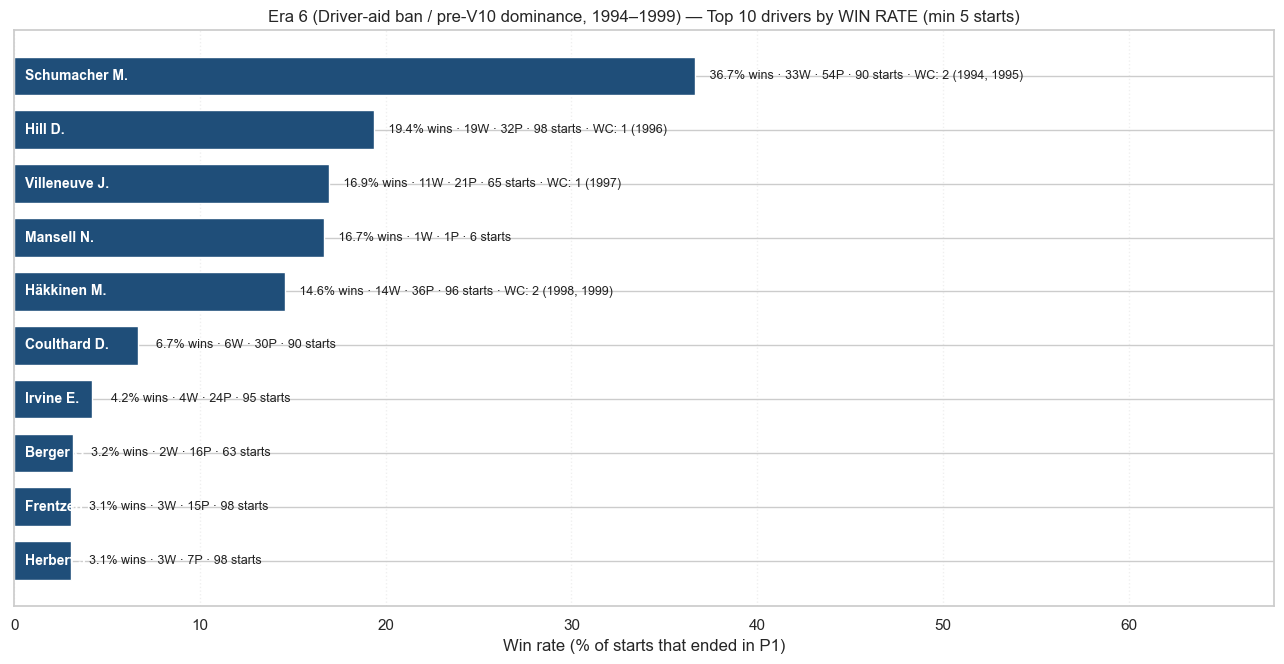

In [ ]:
plot_era_top_drivers(era_id=6)


### Era 6 — Wins per constructor per season (chart 6.2)

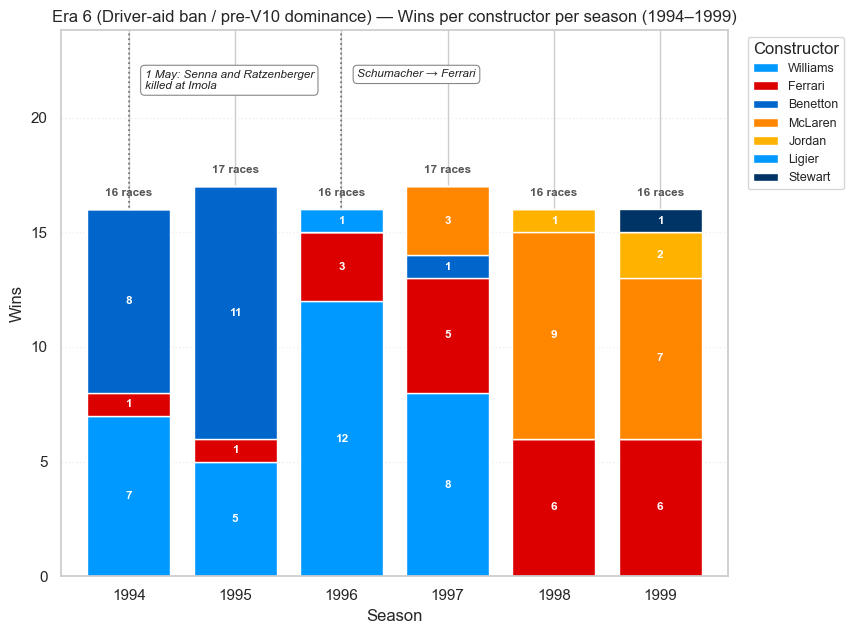

In [ ]:
plot_era_wins_per_team(era_id=6)


---
## Era 7 deep-dive — V10 era / Ferrari dominance (2000–2005)

### What defined this era
- **3.0 L V10 engines** reach ~19 000 rpm — the most extreme NA engines in F1 history
- Schumacher + Ferrari win **5 straight titles** (2000–2004) — unprecedented
- 2002 — Schumacher wins **11 of 17 races**; Ferrari wins 15 of 17
- 2004 — Schumacher's peak: **13 of 18 wins**, 5th straight title
- 2005 — Renault and Alonso end the Ferrari run

### Defining drivers
| Driver | Titles in Era 7 | Seasons (constructor) |
|---|---|---|
| **Michael Schumacher** | 5 | 2000 → 2004 · all Ferrari (7 career titles total) |
| Fernando Alonso | 1 (Era 7) | 2005 · Renault — **youngest WC at 24** (record at the time) |

### Key historical events
- **2000** — Schumacher's first Ferrari title (the team's first since Scheckter 1979)
- **2002** — Ferrari wins all but 2 races; "no team orders" rule for 2003
- **2004** — Schumacher 13 wins of 18 — his peak year
- **2005** — Alonso ends the Ferrari run; one-tyre-per-race rule


### Era 7 — Top 10 drivers by win rate (chart 6.1)

Era 7 (V10 era, 2000–2005) — Top 10 drivers by win rate (min 5 starts):
          driver win_rate  wins  podiums  starts  titles                  title_years
   Schumacher M.    47.1%    49       71     104       5 2000, 2001, 2002, 2003, 2004
     Häkkinen M.    17.6%     6       14      34       0                             
       Alonso F.    11.4%     8       23      70       1                         2005
    Räikkönen K.    10.3%     9       30      87       0                             
  Barrichello R.     8.7%     9       55     104       0                             
Pablo Montoya J.     8.2%     7       28      85       0                             
    Coulthard D.     6.7%     7       30     104       0                             
   Schumacher R.     6.2%     6       20      96       0                             
   Fisichella G.     1.9%     2        8     104       0                             
       Trulli J.     1.0%     1        6     103       0            

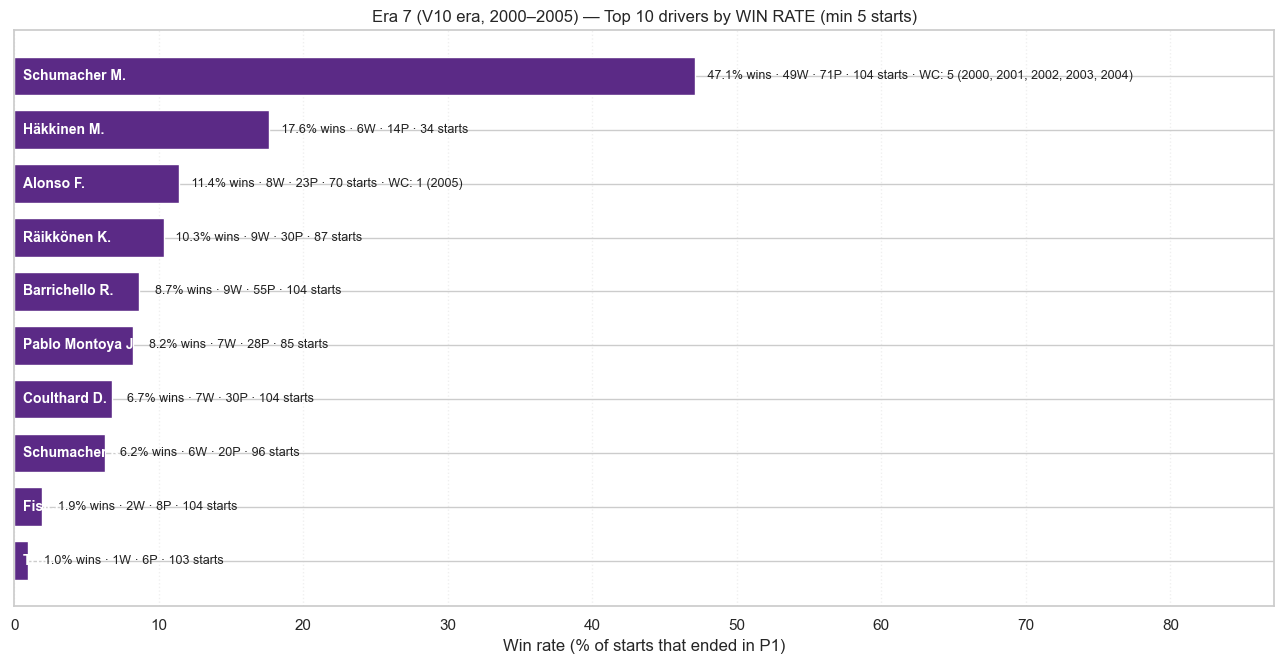

In [ ]:
plot_era_top_drivers(era_id=7)


### Era 7 — Wins per constructor per season (chart 6.2)

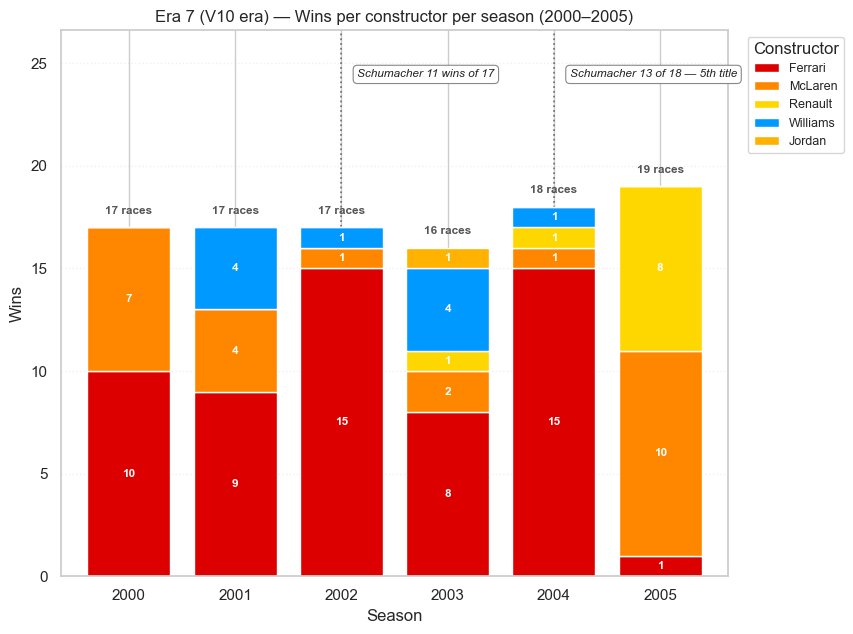

In [ ]:
plot_era_wins_per_team(era_id=7)


---
## Era 8 deep-dive — V8 / Limited electronics (2006–2013)

### What defined this era
- **2.4 L V8** engines replace the V10s
- 2009 — **KERS** (kinetic energy recovery) introduced — first hybrid tech in F1
- 2009 — **Brawn GP fairytale** (Honda → Brawn → Mercedes 1 year later); double-diffuser
- 2011 — **DRS** introduced
- 2010–2013 — Vettel + Red Bull win **4 straight titles**

### Defining drivers
| Driver | Titles in Era 8 | Seasons (constructor) |
|---|---|---|
| **Sebastian Vettel** | 4 | 2010 → 2013 · all Red Bull-Renault — youngest WC at 23 (2010) |
| Fernando Alonso | 1 (Era 8) | 2006 · Renault |
| Kimi Räikkönen | 1 | 2007 · Ferrari — **last Ferrari title to date** |
| Lewis Hamilton | 1 (Era 8) | 2008 · McLaren-Mercedes — by 1 point at the last corner |
| Jenson Button | 1 | 2009 · Brawn-Mercedes — the Brawn fairytale |

### Key historical events
- **2009** — Brawn double-diffuser; KERS introduced; financial crisis
- **2010** — Vettel takes the title at the last race
- **2011** — DRS introduced; Vettel dominant
- **2013** — Vettel's last Red Bull title; V8 era ends


### Era 8 — Top 10 drivers by win rate (chart 6.1)

Era 8 (V8 / Limited electronics, 2006–2013) — Top 10 drivers by win rate (min 5 starts):
        driver win_rate  wins  podiums  starts  titles            title_years
     Vettel S.    32.5%    39       62     120       4 2010, 2011, 2012, 2013
   Hamilton L.    17.1%    22       54     129       1                   2008
     Alonso F.    16.3%    24       72     147       1                   2006
  Räikkönen K.    10.3%    11       47     107       1                   2007
     Button J.    10.2%    15       37     147       1                   2009
 Schumacher M.     9.2%     7       13      76       0                       
      Massa F.     7.9%    11       36     140       0                       
     Webber M.     6.1%     9       41     147       0                       
    Rosberg N.     2.0%     3       11     147       0                       
Barrichello R.     1.9%     2        7     108       0                       


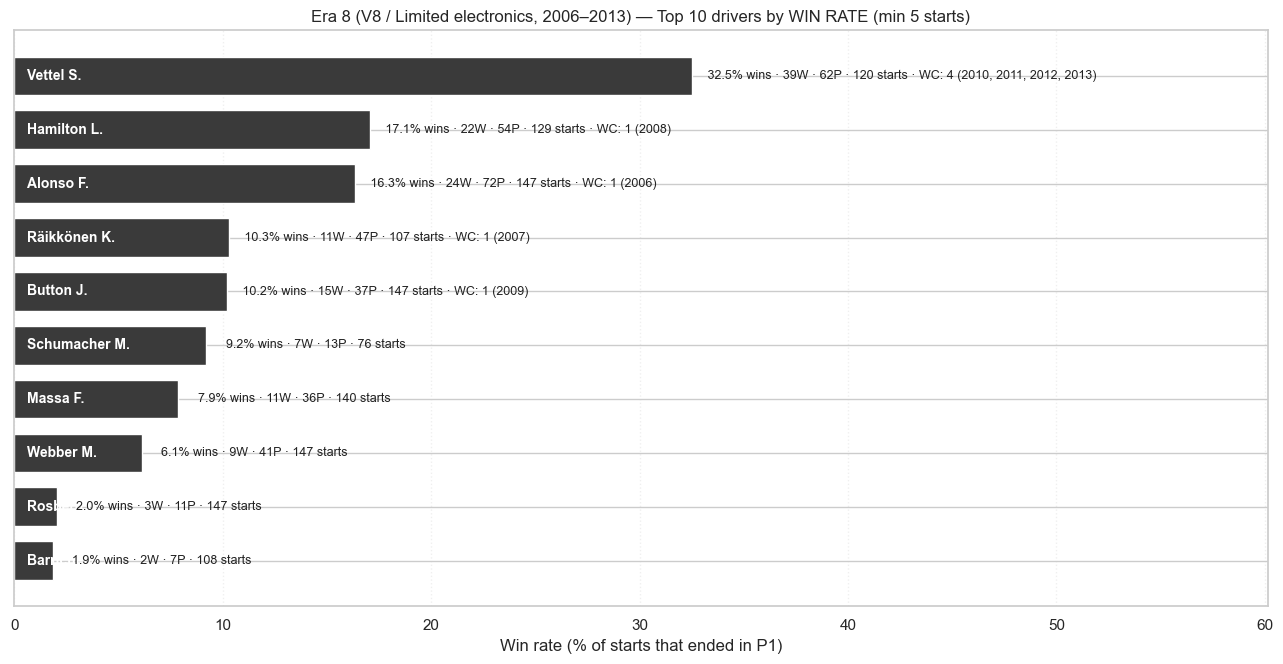

In [ ]:
plot_era_top_drivers(era_id=8)


### Era 8 — Wins per constructor per season (chart 6.2)

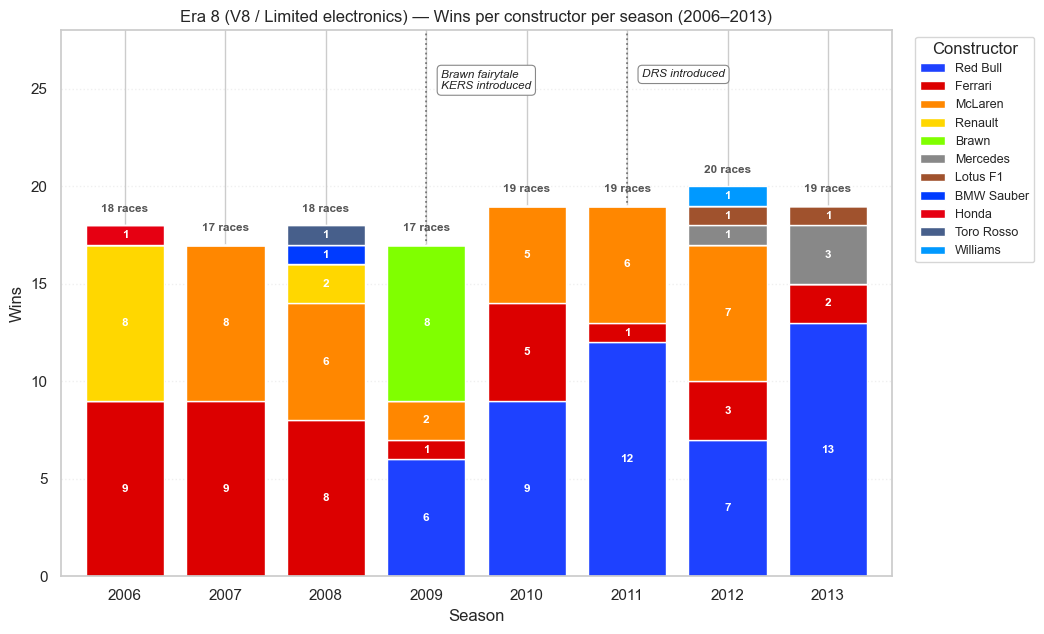

In [ ]:
plot_era_wins_per_team(era_id=8)


---
## Era 9 deep-dive — Hybrid V6 Turbo (2014–present)

### What defined this era
- **1.6 L V6 turbo + hybrid** (MGU-K + MGU-H) — extremely complex power units
- Mercedes power-unit dominance from day one — won every Constructors' title 2014–2021 (8 in a row)
- 2018 — **halo** safety device introduced
- 2021 — Verstappen ends the Mercedes title streak; controversial Abu Dhabi finale
- 2022 — ground-effect cars return (full aero rules reset)

### Defining drivers
| Driver | Titles in Era 9 | Seasons (constructor) |
|---|---|---|
| **Lewis Hamilton** | 6 | 2014, 2015, 2017, 2018, 2019, 2020 · Mercedes — record-tying 7th overall (2020) |
| **Max Verstappen** | 4 | 2021, 2022, 2023, 2024 · Red Bull-Honda |
| Nico Rosberg | 1 | 2016 · Mercedes — **retired the same week** he won the title |

### Key historical events
- **2014** — V6 turbo-hybrid era begins; Mercedes immediately dominant
- **2016** — Rosberg wins title and retires the same week
- **2018** — Halo introduced
- **2021** — Verstappen vs Hamilton; controversial Abu Dhabi safety-car decision
- **2022** — ground-effect aero rules; Red Bull take over


### Era 9 — Top 10 drivers by win rate (chart 6.1)

Era 9 (Hybrid V6 Turbo, 2014–2025) — Top 10 drivers by win rate (min 5 starts):
       driver win_rate  wins  podiums  starts  titles                        title_years
  Hamilton L.    36.6%    83      148     227       6 2014, 2015, 2017, 2018, 2019, 2020
   Rosberg N.    33.9%    20       46      59       1                               2016
Verstappen M.    30.1%    63      112     209       4             2021, 2022, 2023, 2024
    Vettel S.     7.8%    14       60     180       0                                   
   Leclerc C.     5.4%     8       43     149       0                                   
    Bottas V.     4.4%    10       67     228       0                                   
   Piastri O.     4.3%     2       10      46       0                                   
 Ricciardo D.     3.9%     8       32     207       0                                   
    Norris L.     3.1%     4       26     128       0                                   
     Pérez S.     2.7%     6  

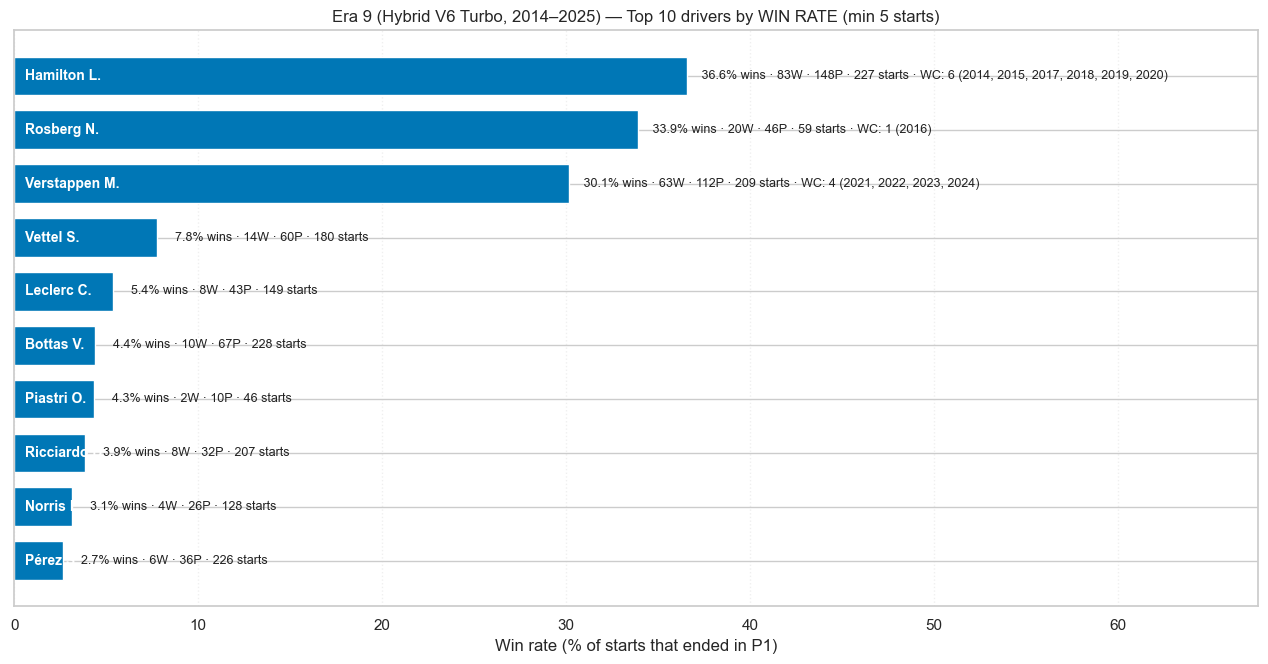

In [ ]:
plot_era_top_drivers(era_id=9)


### Era 9 — Wins per constructor per season (chart 6.2)

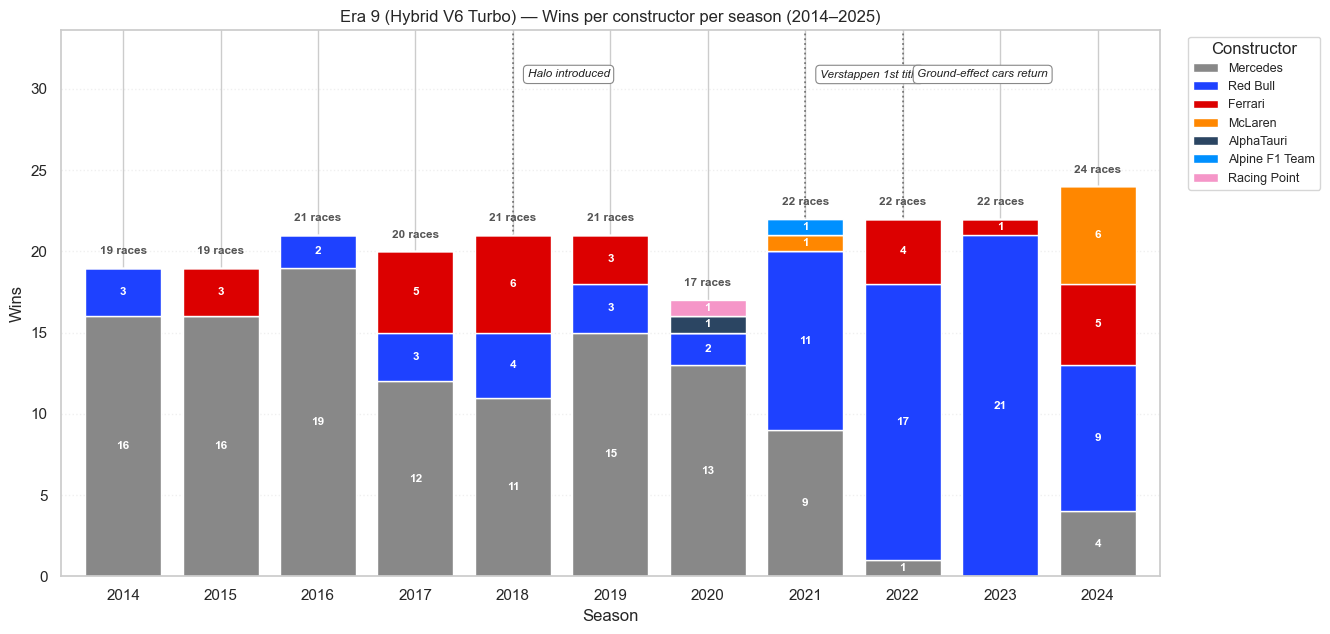

In [ ]:
plot_era_wins_per_team(era_id=9)


---
## Cross-era analyses (Q6.2a – Q6.6)

The era deep-dives above (6.1 / 6.2) answered the same two questions nine times — once per era. The charts below zoom out and put **all eras on the same axes**, which is the only way to actually *compare* them visually.

| # | Question |
|---|---|
| 6.2a | All eras on one chart — driver win rate vs year, era-colored (cross-era scatterplot) |
| 6.2b | Era competitiveness gap — win rate of #1 driver minus #10 driver per era |
| 6.3  | Drivers who raced across the most eras |
| 6.4  | Within-season pattern (early vs mid vs late races) per era |
| 6.5  | Change in points distribution between seasons (normalized for race count) |
| 6.6  | (meta) where to apply mean / mode / variance |

6.2a + 6.2b are the analytical highlight — they answer *"is the modern era more or less competitive than the wings & aero era?"* with one chart instead of forcing the reader to mentally compare nine separate plots.


### Chart 6.2a — All eras on one chart (cross-era scatterplot)

For every driver-era combination (min 5 starts in that era), plot:

- **x** = midpoint year of their activity in that era
- **y** = win rate within that era
- **color** = era
- **size** = number of starts in that era (bigger dot = bigger sample)

This is the chart that lets you compare Fangio (Era 1, ~47 % win rate over ~50 starts) directly against Verstappen (Era 9, ~30 %+ over ~200 starts) on the same axes. The dot **size** tells you how seriously to take each point — small dots are short careers and can be flukes; big dots are sustained dominance.


Total driver-era points (min 5 starts): 633


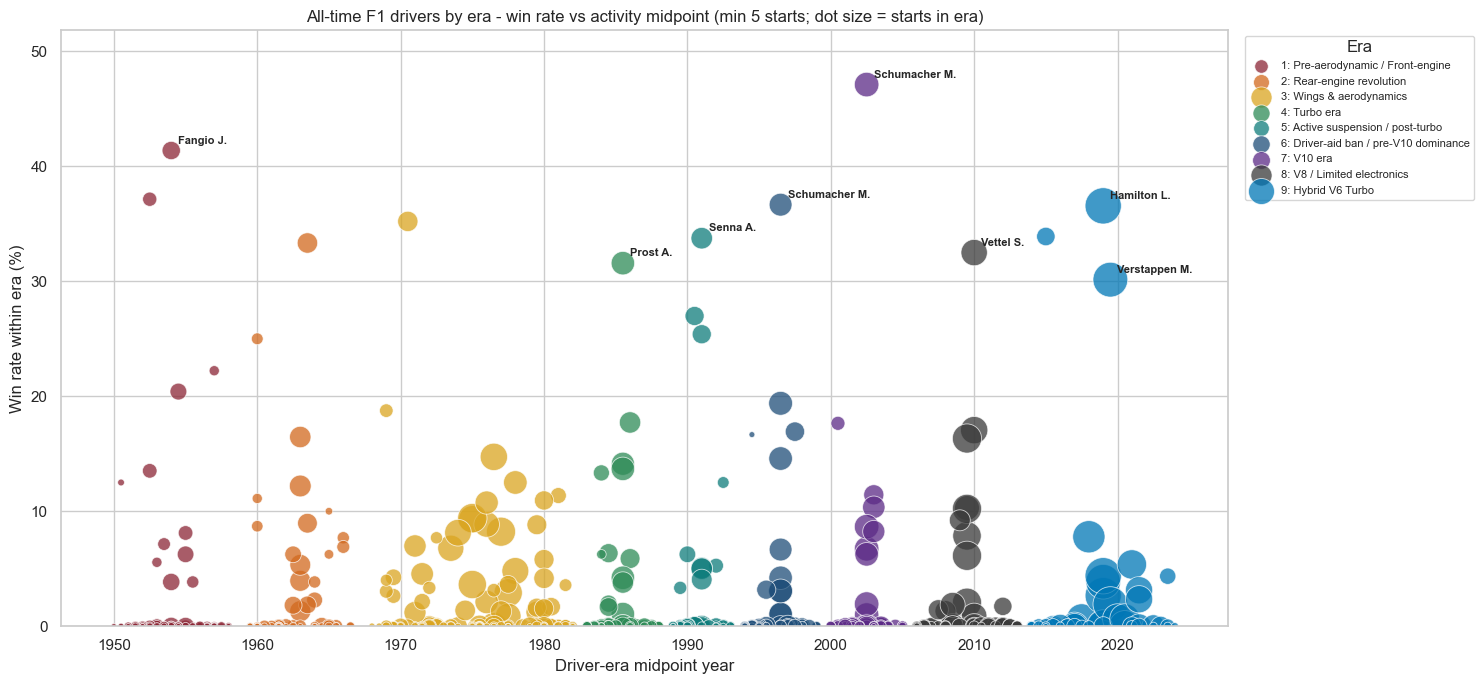


TOP 10 driver-era performances by win rate (min 5 starts):
       driver                            name_en  starts  wins  win_rate_pct
Schumacher M.                            V10 era     104    49          47.1
    Fangio J.     Pre-aerodynamic / Front-engine      58    24          41.4
    Ascari A.     Pre-aerodynamic / Front-engine      35    13          37.1
Schumacher M. Driver-aid ban / pre-V10 dominance      90    33          36.7
  Hamilton L.                    Hybrid V6 Turbo     227    83          36.6
   Stewart J.               Wings & aerodynamics      71    25          35.2
   Rosberg N.                    Hybrid V6 Turbo      59    20          33.9
     Senna A.     Active suspension / post-turbo      80    27          33.8
     Clark J.             Rear-engine revolution      72    24          33.3
    Vettel S.           V8 / Limited electronics     120    39          32.5


In [ ]:
# Reuse _era_results() from the helper cell. We compute per-(driver, era)
# win rate + sample size, filter for min starts, and scatter-plot.

MIN_STARTS = 5

# Build a compact name column on-the-fly (Surname F.) — drivers.csv has only
# the raw columns in this notebook.
drivers_named = drivers.assign(
    driver=lambda d: d['surname'] + ' ' + d['forename'].str[0] + '.'
)

# Loop over all 9 eras, collecting each driver's activity within them
rows = []
for era_id in eras_df['era_id']:
    er = _era_results(era_id)
    grp = er.groupby('driverId').agg(starts=('raceId', 'count'),
                                      wins=('positionOrder', lambda p: (p == 1).sum()),
                                      year_min=('year', 'min'),
                                      year_max=('year', 'max')).reset_index()
    grp = grp[grp['starts'] >= MIN_STARTS].copy()
    grp['era_id'] = era_id
    grp['win_rate_pct'] = grp['wins'] / grp['starts'] * 100
    grp['year_mid'] = (grp['year_min'] + grp['year_max']) / 2
    rows.append(grp)

scatter_df = pd.concat(rows, ignore_index=True).merge(
    drivers_named[['driverId', 'driver']], on='driverId'
)
print(f'Total driver-era points (min {MIN_STARTS} starts): {len(scatter_df)}')

# Plot — one scatter per era so the legend builds itself
fig, ax = plt.subplots(figsize=(15, 7))
for era_id, grp in scatter_df.groupby('era_id'):
    name = eras_df.loc[eras_df['era_id'] == era_id, 'name_en'].iloc[0]
    ax.scatter(grp['year_mid'], grp['win_rate_pct'],
               s=grp['starts'] * 3,
               color=ERA_COLORS[era_id],
               edgecolor='white', linewidth=0.6, alpha=0.75,
               label=f'{era_id}: {name}')

# Annotate the most notable dots — high win rate AND meaningful sample size
scatter_df['notability'] = scatter_df['win_rate_pct'] * (scatter_df['starts'] ** 0.5)
for row in scatter_df.nlargest(8, 'notability').itertuples():
    ax.annotate(row.driver,
                xy=(row.year_mid, row.win_rate_pct),
                xytext=(5, 5), textcoords='offset points',
                fontsize=8, fontweight='bold')

ax.set_xlabel('Driver-era midpoint year')
ax.set_ylabel('Win rate within era (%)')
ax.set_title(f'All-time F1 drivers by era - win rate vs activity midpoint '
             f'(min {MIN_STARTS} starts; dot size = starts in era)')
ax.legend(title='Era', loc='upper left', bbox_to_anchor=(1.01, 1.0),
          frameon=True, fontsize=8)
ax.set_ylim(0, scatter_df['win_rate_pct'].max() * 1.1)
plt.tight_layout()
show_and_save('6.2a_cross_era_scatter.png')


# Top 10 driver-era performances by win rate
print()
print(f'TOP 10 driver-era performances by win rate (min {MIN_STARTS} starts):')
top10 = (scatter_df.nlargest(10, 'win_rate_pct')
         .merge(eras_df[['era_id', 'name_en']], on='era_id')
         [['driver', 'name_en', 'starts', 'wins', 'win_rate_pct']]
         .round({'win_rate_pct': 1}))
print(top10.to_string(index=False))


### Chart 6.2b — Era competitiveness gap

For each era, take its top 10 drivers (by win rate, min 5 starts) and compute the **gap** between #1 and #10. A large gap = one dominant driver towering over the field; a small gap = a deep, competitive era.

This operationalizes the "concentration at the top" observation from the key insights: instead of just listing it, we measure and rank it.


Era competitiveness gap (P1 win rate - P10 win rate):
 era_id                            name_en  year_start  year_end        driver  p1_win_rate  p10_win_rate  gap
      1     Pre-aerodynamic / Front-engine        1950      1958     Fangio J.         41.4           5.6 35.8
      2             Rear-engine revolution        1959      1967      Clark J.         33.3           6.9 26.4
      3               Wings & aerodynamics        1968      1982    Stewart J.         35.2           8.8 26.4
      4                          Turbo era        1983      1988      Prost A.         31.6           3.8 27.8
      5     Active suspension / post-turbo        1989      1993      Senna A.         33.8           3.3 30.4
      6 Driver-aid ban / pre-V10 dominance        1994      1999 Schumacher M.         36.7           3.1 33.6
      7                            V10 era        2000      2005 Schumacher M.         47.1           1.0 46.1
      8           V8 / Limited electronics        2006    

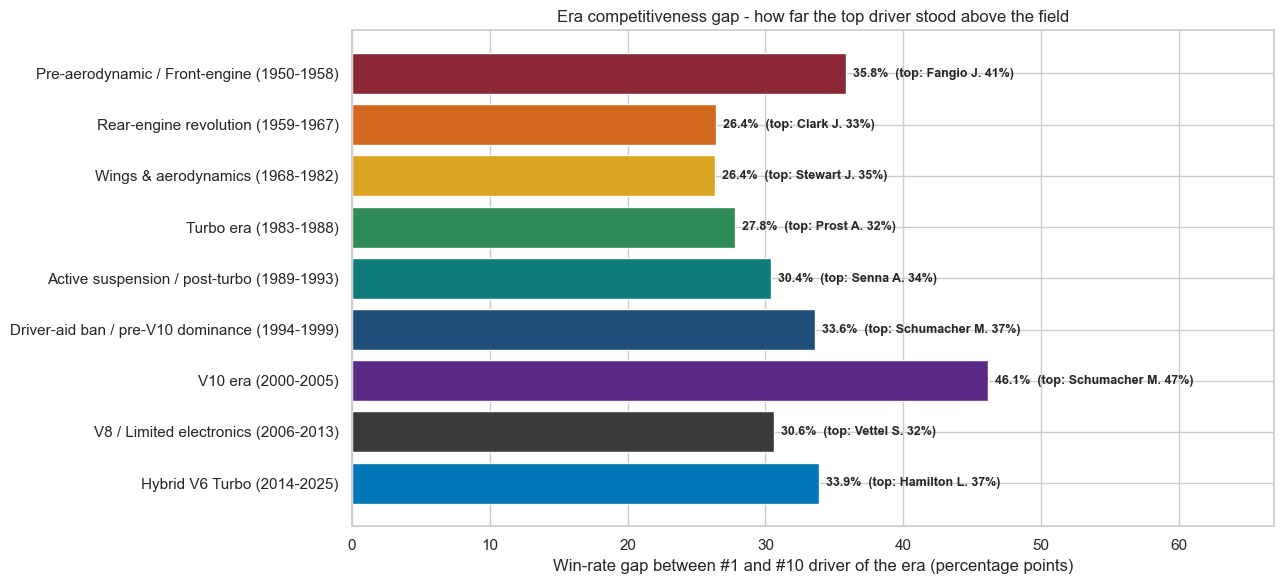

In [ ]:
# For each era, rebuild the same top-10 used by plot_era_top_drivers() and compute
# the win-rate spread.

drivers_named = drivers.assign(
    driver=lambda d: d['surname'] + ' ' + d['forename'].str[0] + '.'
)

rows = []
for era_id in eras_df['era_id']:
    er = _era_results(era_id)
    grp = (er.groupby('driverId')
             .agg(starts=('raceId', 'count'),
                  wins=('positionOrder', lambda p: (p == 1).sum()))
             .reset_index())
    grp = grp[grp['starts'] >= 5].copy()
    grp['win_rate_pct'] = grp['wins'] / grp['starts'] * 100
    top10_era = grp.nlargest(10, 'win_rate_pct')
    if len(top10_era) < 2:
        continue
    rows.append({
        'era_id': era_id,
        'p1_win_rate': top10_era['win_rate_pct'].iloc[0],
        'p10_win_rate': top10_era['win_rate_pct'].iloc[-1],
        'gap': top10_era['win_rate_pct'].iloc[0] - top10_era['win_rate_pct'].iloc[-1],
        'top_driver_id': int(top10_era['driverId'].iloc[0]),
    })

gap_df = (pd.DataFrame(rows)
          .merge(eras_df[['era_id', 'name_en', 'year_start', 'year_end']], on='era_id')
          .merge(drivers_named[['driverId', 'driver']],
                 left_on='top_driver_id', right_on='driverId', how='left'))

print('Era competitiveness gap (P1 win rate - P10 win rate):')
print(gap_df[['era_id', 'name_en', 'year_start', 'year_end',
              'driver', 'p1_win_rate', 'p10_win_rate', 'gap']]
      .round({'p1_win_rate': 1, 'p10_win_rate': 1, 'gap': 1})
      .to_string(index=False))


# Horizontal bar chart, era_id 1 at top
fig, ax = plt.subplots(figsize=(13, 6))
plot_df = gap_df.sort_values('era_id', ascending=False)
bar_colors = [ERA_COLORS[e] for e in plot_df['era_id']]
y = range(len(plot_df))
ax.barh(y, plot_df['gap'], color=bar_colors, edgecolor='white')

labels = (plot_df['name_en']
          + ' ('
          + plot_df['year_start'].astype(str) + '-'
          + plot_df['year_end'].astype(str) + ')')
ax.set_yticks(list(y))
ax.set_yticklabels(labels)

for i, row in enumerate(plot_df.itertuples()):
    ax.text(row.gap + 0.5, i,
            f'{row.gap:.1f}%  (top: {row.driver} {row.p1_win_rate:.0f}%)',
            va='center', fontsize=9, fontweight='bold')

ax.set_xlim(0, plot_df['gap'].max() * 1.45)
ax.set_xlabel('Win-rate gap between #1 and #10 driver of the era (percentage points)')
ax.set_title('Era competitiveness gap - how far the top driver stood above the field')
plt.tight_layout()
show_and_save('6.2b_era_competitiveness_gap.png')


### Chart 6.3 — Drivers who raced across the most eras

Same calculation as **Q2.6** in the Driver-career notebook, replicated here so the era notebook is self-contained. Counts how many of the 9 eras each driver had at least one race in.

A driver who raced 1990 and 1995 spans 2 eras (5 ↔ 6), even though only 5 calendar years elapsed. Era boundaries don't align with decades — that's why this gives different numbers than a "decades raced" count.


Top 10 drivers by number of eras raced:
        driver  eras  first_year  last_year
    Mansell N.     4        1980       1995
     Moreno R.     4        1982       1995
   Alboreto M.     4        1981       1994
 de Cesaris A.     4        1980       1994
Barrichello R.     4        1993       2011
 Schumacher M.     4        1991       2012
  Räikkönen K.     3        2001       2021
     Alonso F.     3        2001       2024
     Button J.     3        2000       2017
      Massa F.     3        2002       2017


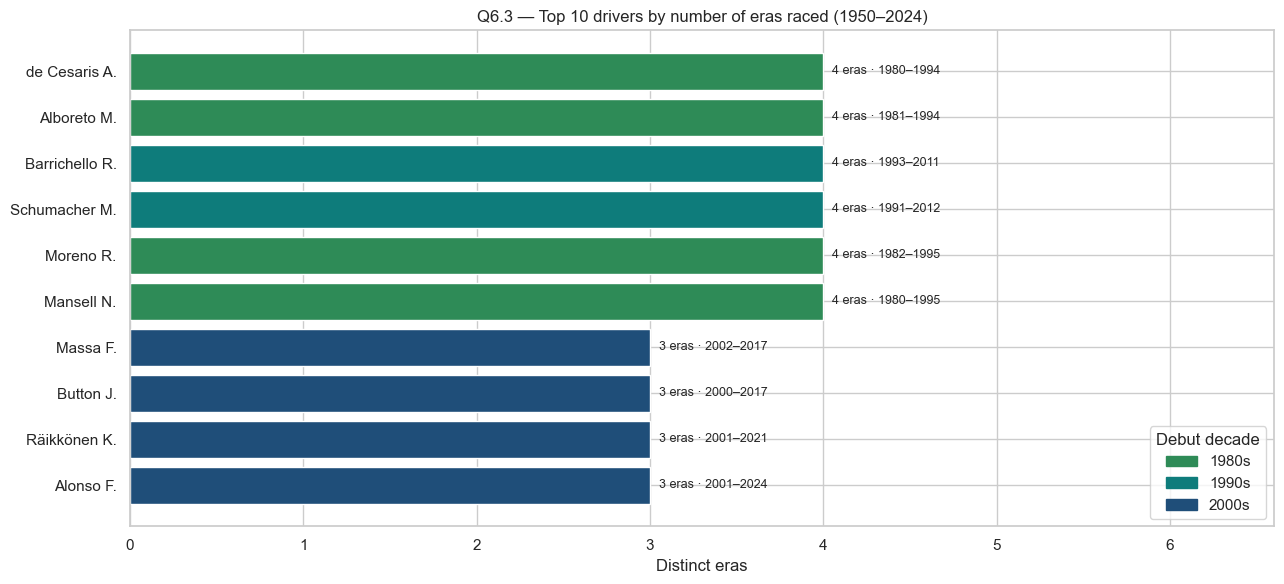

In [ ]:
# Re-use eras_df defined earlier in this notebook + the races dataframe with era_id
driver_era_pairs = (
    results.merge(races[['raceId', 'year', 'era_id']], on='raceId')
    .dropna(subset=['era_id'])
    [['driverId', 'era_id', 'year']]
    .drop_duplicates()
)

eras_per_driver = (
    driver_era_pairs.groupby('driverId')
    .agg(eras=('era_id', 'nunique'),
         first_year=('year', 'min'),
         last_year=('year', 'max'))
    .reset_index()
    .merge(drivers[['driverId', 'forename', 'surname']], on='driverId')
)
eras_per_driver['driver'] = eras_per_driver['surname'] + ' ' + eras_per_driver['forename'].str[0] + '.'
eras_per_driver['debut_decade'] = (eras_per_driver['first_year'] // 10) * 10

top10_eras = (eras_per_driver
              .sort_values(['eras', 'last_year'], ascending=[False, False])
              .head(10)
              .sort_values('eras'))

print('Top 10 drivers by number of eras raced:')
print(top10_eras.sort_values('eras', ascending=False)
      [['driver', 'eras', 'first_year', 'last_year']].to_string(index=False))

DECADE_PALETTE = {
    1950: '#8B2635', 1960: '#D2691E', 1970: '#DAA520', 1980: '#2E8B57',
    1990: '#0E7C7B', 2000: '#1F4E79', 2010: '#5B2A86', 2020: '#3A3A3A',
}

plt.figure(figsize=(13, 6))
bar_colors = [DECADE_PALETTE[d] for d in top10_eras['debut_decade']]
plt.barh(range(len(top10_eras)), top10_eras['eras'], color=bar_colors)
plt.yticks(range(len(top10_eras)), top10_eras['driver'])

for i, row in enumerate(top10_eras.itertuples()):
    plt.text(row.eras + 0.05, i,
             f'{row.eras} eras · {int(row.first_year)}–{int(row.last_year)}',
             va='center', fontsize=9)

used = sorted(top10_eras['debut_decade'].unique())
handles = [plt.Rectangle((0, 0), 1, 1, color=DECADE_PALETTE[d], label=f'{d}s')
           for d in used]
plt.legend(handles=handles, title='Debut decade', loc='lower right', frameon=True)

plt.title('Q6.3 — Top 10 drivers by number of eras raced (1950–2024)')
plt.xlabel('Distinct eras')
plt.ylabel('')
plt.xlim(0, top10_eras['eras'].max() * 1.65)
plt.tight_layout()
plt.savefig('charts/6.3_drivers_most_eras.png', dpi=150, bbox_inches='tight')
plt.show()


**SQL equivalent** — identical to the SQL in Q2.6 (drivers across the most eras). See the *Driver Career & Milestones* notebook.


### Chart 6.4 — Within-season pattern: early vs mid vs late races, per era

For each season, divide the calendar into three thirds by round number (early, mid, late). For each (era, third), compute two metrics:

- **DNF rate** — fraction of all driver-results that were a non-classified finish.
- **Position-1 lock-in** — fraction of races in that third where the eventual champion was already first in standings (a proxy for "title resolved early").

Comparing these three thirds across eras shows whether **rule changes** (which kick in at season start) and **mid-season development** (which only impacts later races) created systematically different patterns era-by-era. Reliability-era seasons (60s/70s) typically have a high early-season DNF rate that drops by season's end; modern seasons are flat.


DNF % per (era, season-third):
                                    early   mid  late
name_en                                              
Pre-aerodynamic / Front-engine       52.0  46.7  53.0
Rear-engine revolution               57.7  52.1  52.8
Wings & aerodynamics                 55.3  54.2  56.3
Turbo era                            60.4  59.4  59.3
Active suspension / post-turbo       66.4  59.8  59.5
Driver-aid ban / pre-V10 dominance   53.7  52.3  43.9
V10 era                              38.9  37.6  32.7
V8 / Limited electronics             26.5  20.9  20.7
Hybrid V6 Turbo                      17.5  17.6  16.8


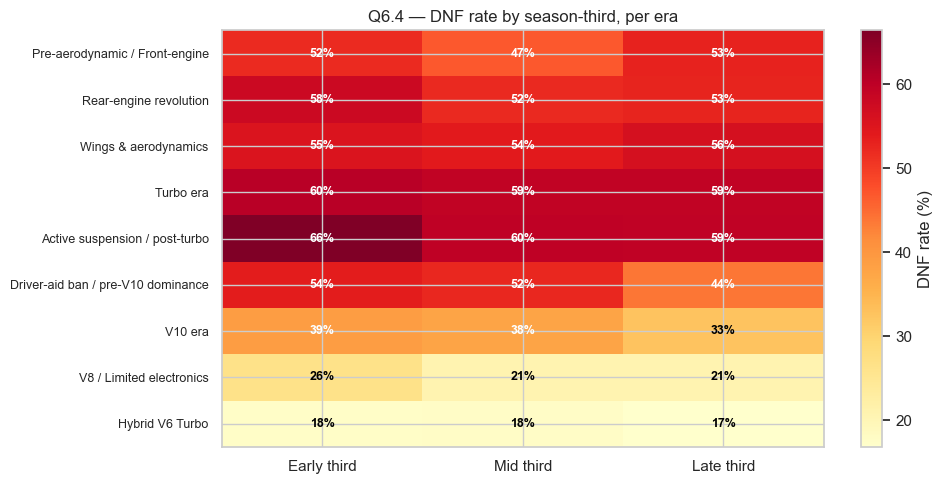

In [ ]:
# Per-race round → which season-third (1, 2, 3)
race_pos = races.copy()
race_pos['final_round'] = race_pos.groupby('year')['round'].transform('max')
race_pos['third'] = pd.cut(race_pos['round'] / race_pos['final_round'],
                           bins=[0, 1/3, 2/3, 1.001],
                           labels=['early', 'mid', 'late'])

# Status table — used to label classified vs DNF
status = pd.read_csv('excel/status.csv')
finished_ids = set(status[(status['status'] == 'Finished') |
                          status['status'].str.startswith('+')]['statusId'])
results_local = results.copy()
results_local['is_finish'] = results_local['statusId'].isin(finished_ids)

results_full = (results_local.merge(race_pos[['raceId', 'year', 'era_id', 'third']],
                                    on='raceId')
                .dropna(subset=['era_id', 'third']))

# Per (era, third) DNF rate
dnf_rate = (results_full.groupby(['era_id', 'third'], observed=True)
            .agg(n=('raceId', 'count'),
                 dnfs=('is_finish', lambda s: (~s).sum()))
            .reset_index())
dnf_rate['dnf_pct'] = dnf_rate['dnfs'] / dnf_rate['n'] * 100

print('DNF % per (era, season-third):')
pivot = (dnf_rate.pivot(index='era_id', columns='third', values='dnf_pct')
         .merge(eras_df[['era_id', 'name_en']], on='era_id')
         .set_index('name_en')
         [['early', 'mid', 'late']])
print(pivot.round(1).to_string())


# Heatmap-style chart — rows = era, columns = third, cell = DNF%
fig, ax = plt.subplots(figsize=(10, 5))
data = pivot.values
im = ax.imshow(data, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(3))
ax.set_xticklabels(['Early third', 'Mid third', 'Late third'])
ax.set_yticks(range(len(pivot)))
ax.set_yticklabels(pivot.index, fontsize=9)

for i in range(len(pivot)):
    for j in range(3):
        v = data[i, j]
        ax.text(j, i, f'{v:.0f}%', ha='center', va='center',
                color='white' if v > data.max() * 0.55 else 'black',
                fontsize=9, fontweight='bold')

ax.set_title('Q6.4 — DNF rate by season-third, per era')
plt.colorbar(im, ax=ax, label='DNF rate (%)')
plt.tight_layout()
plt.savefig('charts/6.4_dnf_by_season_third.png', dpi=150, bbox_inches='tight')
plt.show()


**SQL equivalent**
```sql
-- 6.4: DNF % by (era, season-third). Round / max_round bucketed into thirds.
WITH race_third AS (
    SELECT
        ra.raceId, ra.year, ra.era_id, ra.round,
        MAX(ra.round) OVER (PARTITION BY ra.year) AS final_round,
        CASE
            WHEN ra.round * 1.0 / MAX(ra.round) OVER (PARTITION BY ra.year) <= 1.0/3 THEN 'early'
            WHEN ra.round * 1.0 / MAX(ra.round) OVER (PARTITION BY ra.year) <= 2.0/3 THEN 'mid'
            ELSE 'late'
        END AS third
    FROM   races ra
    WHERE  ra.name NOT LIKE '%Indianapolis%'
)
SELECT
    rt.era_id, rt.third,
    COUNT(*) AS n,
    SUM(CASE WHEN s.status <> 'Finished' AND s.status NOT LIKE '+%' THEN 1 ELSE 0 END) AS dnfs,
    100.0 * SUM(CASE WHEN s.status <> 'Finished' AND s.status NOT LIKE '+%' THEN 1 ELSE 0 END) / COUNT(*) AS dnf_pct
FROM   results r
JOIN   race_third rt ON r.raceId = rt.raceId
JOIN   status     s  ON r.statusId = s.statusId
GROUP  BY rt.era_id, rt.third
ORDER  BY rt.era_id, rt.third;
```


### Chart 6.5 — Change in points distribution between seasons (normalized for race count)

Per season, build the **points-per-race** distribution across all drivers (each driver's total season points divided by the number of races they entered). Then plot two summary statistics over time:

- **Standard deviation** — how spread out is the field? Higher = bigger gap between dominant driver and the rest.
- **Coefficient of variation (std / mean)** — same but scale-free, so comparable across scoring systems.

Because both metrics are computed from per-race averages, they are robust to season length (1950 with 6 races vs 2024 with 24).


Points-per-race spread per season (head + tail):
 year  mean   std    cv  decade
 1950 1.288 1.581 1.227    1950
 1951 1.264 1.572 1.244    1950
 1952 0.910 1.902 2.091    1950
 1953 0.990 1.537 1.552    1950
 1954 1.063 1.555 1.463    1950
 1955 1.143 1.621 1.419    1950
 1956 0.900 1.131 1.257    1950
 1957 1.314 1.574 1.198    1950
...
 year  mean   std    cv  decade
 2017 4.608 5.737 1.245    2010
 2018 5.050 5.804 1.149    2010
 2019 5.095 5.912 1.160    2010
 2020 5.109 5.416 1.060    2020
 2021 4.978 5.347 1.074    2020
 2022 5.100 5.849 1.147    2020
 2023 4.673 5.831 1.248    2020
 2024 4.580 5.464 1.193    2020


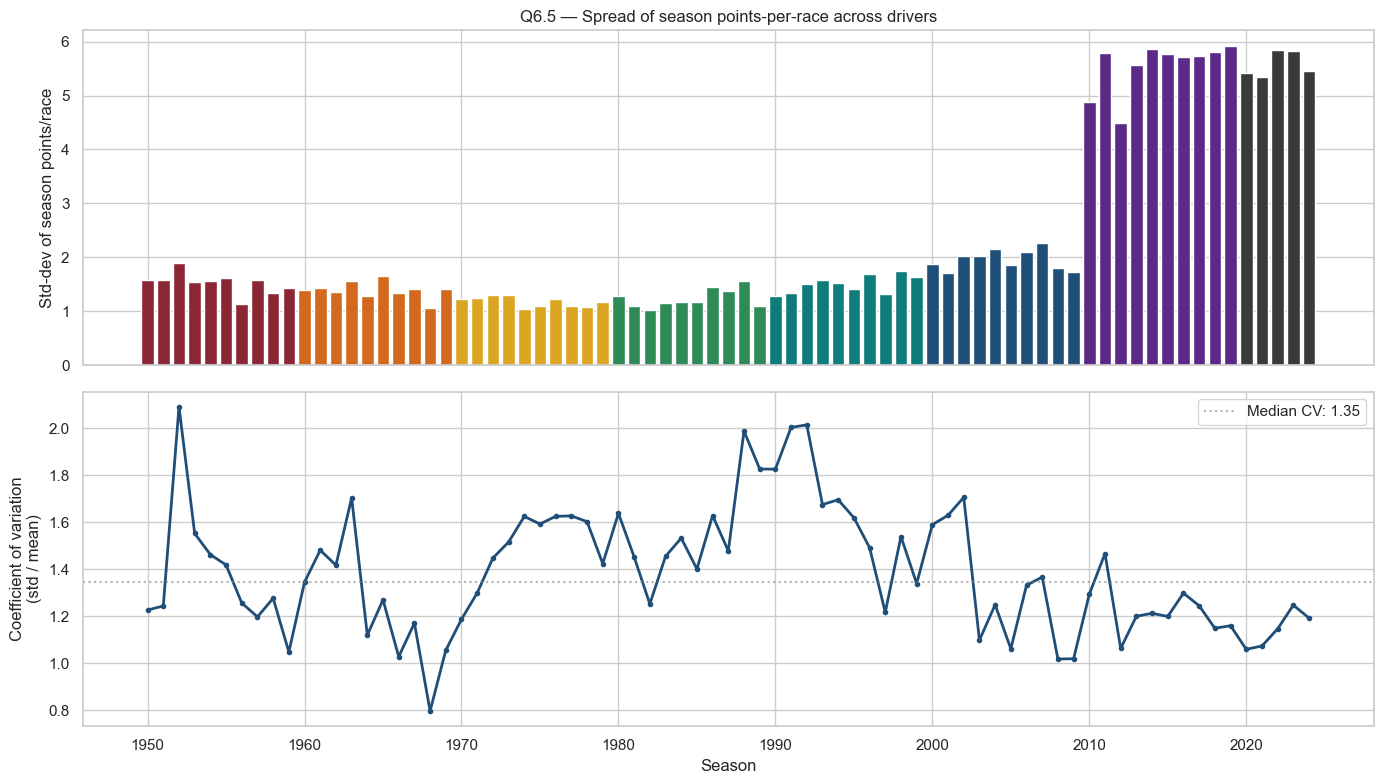

In [ ]:
# Per (driver, year): total points and races entered
dy = (results.merge(races[['raceId', 'year']], on='raceId')
      .groupby(['driverId', 'year'])
      .agg(points=('points', 'sum'),
           races_entered=('raceId', 'count'))
      .reset_index())
dy['ppr'] = dy['points'] / dy['races_entered']  # points per race entered

# Drop driver-seasons with very few starts — small samples skew the std/CV
dy = dy[dy['races_entered'] >= 3]

dist = (dy.groupby('year')['ppr']
        .agg(['mean', 'std'])
        .reset_index())
dist['cv'] = dist['std'] / dist['mean']
dist['decade'] = (dist['year'] // 10) * 10

print('Points-per-race spread per season (head + tail):')
print(dist.head(8).round(3).to_string(index=False))
print('...')
print(dist.tail(8).round(3).to_string(index=False))


fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: standard deviation
axes[0].bar(dist['year'], dist['std'],
            color=[DECADE_PALETTE[d] for d in dist['decade']],
            edgecolor='white')
axes[0].set_ylabel('Std-dev of season points/race')
axes[0].set_title('Q6.5 — Spread of season points-per-race across drivers')

# Bottom: coefficient of variation
axes[1].plot(dist['year'], dist['cv'], color='#1F4E79', linewidth=2,
             marker='o', markersize=3)
axes[1].set_ylabel('Coefficient of variation\n(std / mean)')
axes[1].set_xlabel('Season')
axes[1].axhline(dist['cv'].median(), color='gray', linestyle=':', alpha=0.6,
                label=f'Median CV: {dist["cv"].median():.2f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('charts/6.5_points_distribution_change.png', dpi=150, bbox_inches='tight')
plt.show()


**SQL equivalent**
```sql
-- 6.5: Std-dev and CV of points-per-race per season (drivers with >=3 races)
WITH driver_year AS (
    SELECT
        r.driverId, ra.year,
        SUM(r.points)            AS season_pts,
        COUNT(*)                 AS races_entered,
        SUM(r.points) * 1.0 / COUNT(*) AS ppr
    FROM   results r
    JOIN   races   ra ON r.raceId = ra.raceId
    WHERE  ra.name NOT LIKE '%Indianapolis%'
    GROUP  BY r.driverId, ra.year
    HAVING COUNT(*) >= 3
)
SELECT
    year,
    AVG(ppr)        AS mean_ppr,
    STDDEV(ppr)     AS std_ppr,            -- or use a manual SQRT(VAR) if no STDDEV
    STDDEV(ppr) / NULLIF(AVG(ppr),0) AS cv
FROM   driver_year
GROUP  BY year
ORDER  BY year;
```


### 6.6 — Where to apply mean / mode / variance (teaching note)

A short reference for which summary statistic fits which kind of question. Each example uses an outputs-set we already have in this notebook or a sister notebook.

| Statistic | When to use | Risks | F1 example |
|---|---|---|---|
| **Mean** (arithmetic average) | Symmetric, no extreme outliers, scale ratio-style data | Distorted by outliers (a single 25-pt win swamps a 1-pt-each season) | "Average races per year" (5.2) — calendar grew steadily, no outliers, mean is honest |
| **Median** | Skewed distributions; want the *typical* observation | Hides bimodality | "Typical points-scoring driver" — Hamilton's outlier seasons (380+ pts) drag the mean up; the median driver scores ~5–10 pts |
| **Mode** | Categorical or low-resolution data; "most common" is the question | Useless on continuous variables (every value is unique) | "Most common DNF reason" (Q2.3) — `Engine` for almost every long-career driver |
| **Variance / std-dev** | Spread / risk / consistency questions | Very sensitive to outliers (squared deviations) | "Spread of points-per-race across drivers per year" (6.5) — quantifies competitive eras |
| **Coefficient of variation** (std / mean) | Comparing spread *across different scales* | Undefined when mean ≈ 0 | Same chart 6.5 — lets us compare 1950 (mean ≈ 5 pts) to 2024 (mean ≈ 100 pts) on equal footing |
| **Quartile / IQR** | Wide-range data, want a robust spread | Less informative when n is small | "Top quartile of starting grid" — useful for the win-rate-by-grid question (1.8) |
| **Counts / percentages** | Always for funnel-style questions | None really, except sample-size warnings | "Drivers who never won a race" (Q2.9) — count and % of total |

**Two quick rules of thumb that come up in this dataset:**

1. **If the scoring system changed, never compare raw means across that boundary.** Always normalize (per-race, per-max, per-driver-of-the-decade). Most "all-time" league tables in F1 history violate this and silently flatter the modern era.

2. **Compute variance on race-level data, not on season-end totals.** A "low-variance era" usually means *cars were close in single-race performance*, not that *standings were close*. For closeness, use std of **points-per-race** or **lap-time gap to winner** — not std of championship totals (which season length distorts).

---
## Key insights from this notebook

A condensed read-out of what the era-by-era analysis revealed:

1. **Win-rate concentration is high in every era.** Each era has 1–2 drivers
   sitting far above the rest:
   - Era 1: Fangio ~47%, Ascari ~40%
   - Era 7: Schumacher ~40% (peak 65% in 2002 alone)
   - Era 9: Hamilton & Verstappen both ~30%+
   The "competitive midfield" narrative is real, but the *top* of the grid is
   just as dominated as ever.

2. **Schumacher's 2002 season is statistically unmatched** — 11 wins of 17
   races (65%). The highest single-season win rate in modern F1.

3. **The most "open" era was Era 3 (Wings & aerodynamics, 1968–1982)** —
   **11 different World Champions in 15 seasons**. No other era comes close
   to that diversity.

4. **Mercedes' V6 hybrid era was the longest single-team dominance in
   F1 history** — 8 consecutive Constructors' titles (2014–2021). Ferrari's
   2000–2004 was 5 in a row, the previous record.

5. **The first Constructors' Champion (Vanwall, 1958) never won another
   title** — and disappeared from F1 by 1961. Era boundaries can be cruel.

6. **Fangio winning titles for 4 different constructors** (Alfa Romeo,
   Maserati, Mercedes, Ferrari) is unmatched in F1 history. Even Stewart and
   Lauda only won titles for 2 different teams.

7. **Era 6 (1994–1999) shows the post-Senna reset visibly** — the 1994 line
   in Chart 1.13 marks a complete change in the championship landscape.
